In [1]:
# =========================================
# 0) Environment & Random Seed
# =========================================
import os, random, math
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# =========================================
# 1) Parameter section (modify as needed)
# =========================================
CSV_PATH     = r""
ID_COL       = "RID"
TIME_COL     = "Month"

TARGET_MMSE  = "MMSE"   # Regression target
TARGET_DX    = "DX"     # Classification target (encoded as 0/1/2)

# Key change: many subjects start at month 6 → use 6/12/18/24
GRID         = [6, 12, 18, 24]
MIN_REAL_POINTS = 2       # Require at least 2 real months of dynamic inputs

BATCH_SIZE = 64
LR         = 6e-4
EPOCHS     = 300
PATIENCE   = 40

HIDDEN     = 256
N_LAYERS   = 2
DROPOUT    = 0.25  # If you need to re-balance toward regression, try 0.20

LAMBDA_REG = 1.0
LAMBDA_CLS = 1.8   # Slightly pull back classification weight to favor regression

# Avoid stacking "resampling + class weighting/focal" to prevent over-correction
USE_WEIGHTED_SAMPLER = False

MODEL_SAVE = "best_lstm_6_12_18_24.pt"

# =========================================
# 2) Load Data & Auto-detect Static/Dynamic Features
# =========================================
df = pd.read_csv(CSV_PATH)
assert ID_COL in df.columns and TIME_COL in df.columns, "ID or Month column not found"
assert TARGET_MMSE in df.columns, f"Target column {TARGET_MMSE} not found"
assert TARGET_DX   in df.columns, f"Target column {TARGET_DX} not found"

# Consider numeric columns only
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Candidate input features: remove ID/TIME/targets
candidate_cols = [c for c in num_cols if c not in [ID_COL, TIME_COL, TARGET_MMSE, TARGET_DX]]

# Auto-detect static/dynamic (variance=0 within each RID → static)
var_zero_ratio = {}
for c in candidate_cols:
    v = df.groupby(ID_COL)[c].var().fillna(0.0)
    var_zero_ratio[c] = (v == 0).mean()

STATIC_THRESHOLD = 0.8
static_cols_auto  = [c for c, r in var_zero_ratio.items() if r >= STATIC_THRESHOLD]
dynamic_cols_auto = [c for c in candidate_cols if c not in static_cols_auto]

# Optional: remove "config-like" columns from statics (e.g., those starting with BASETP)
ban_statics = [c for c in static_cols_auto if str(c).upper().startswith("BASETP")]
static_cols_auto = [c for c in static_cols_auto if c not in ban_statics]

# Dynamic input features, additionally excluding leakage columns
leak_cols = {TARGET_MMSE, TARGET_DX}
dynamic_in_cols = [c for c in dynamic_cols_auto if c not in leak_cols]

print(f"Auto-detected static features (first 10): {static_cols_auto[:10]}  ... total {len(static_cols_auto)}")
print(f"Auto-detected dynamic features (first 10): {dynamic_in_cols[:10]}  ... total {len(dynamic_in_cols)}")

# DX label mapping (ensure int categories 0/1/2...)
dx_series_num = pd.to_numeric(df[TARGET_DX], errors='coerce')
dx_unique = sorted(dx_series_num.dropna().unique().tolist())
num_classes = len(dx_unique)
dx_to_idx = {int(v): i for i, v in enumerate(dx_unique)}
idx_to_dx = {i: int(v) for i, v in enumerate(dx_unique)}
print("DX label mapping:", dx_to_idx)

# =========================================
# 3) Build Samples: align grid + interpolate + time aux features
#    (use 6/12/18 as input, predict 24)
# =========================================
def choose_dx_label_at_24(sub_df_num):
    """Select the DX label at month 24 without interpolation; if missing, pick the nearest real label (prefer <= 24)."""
    if TARGET_DX not in sub_df_num.columns:
        return None
    dx_series = sub_df_num[TARGET_DX]
    if dx_series.isna().all():
        return None
    if 24 in dx_series.index and not np.isnan(dx_series.loc[24]):
        return int(round(float(dx_series.loc[24])))
    real_months = dx_series.dropna().index.to_list()
    left  = [m for m in real_months if m <= 24]
    right = [m for m in real_months if m >= 24]
    cand = max(left) if len(left) > 0 else (min(right) if len(right) > 0 else None)
    if cand is None or np.isnan(dx_series.loc[cand]):
        return None
    return int(round(float(dx_series.loc[cand])))

def build_subject_tensor(sub_df, grid, dynamic_in_cols, static_cols, target_mmse, target_dx):
    """
    Align to a fixed grid (dynamic + MMSE: linear interpolation; DX: no interpolation).
    Concatenate: dyn + stat + is_obs + delta_m + abs_m
    Returns:
      X: [T, F_in], y_mmse (float, at month 24), y_dx_idx (int), ok (bool)
    """
    sub_df_sorted = sub_df.sort_values(TIME_COL)

    # Static features (first row)
    if len(static_cols) > 0:
        stat_vec = sub_df_sorted.iloc[0][static_cols].values.astype(float)
    else:
        stat_vec = np.zeros((0,), dtype=float)

    # Multiple rows in the same month → take mean over numeric columns by month
    sub_num = sub_df_sorted.set_index(TIME_COL).groupby(level=0).mean(numeric_only=True)

    # Align grid
    grid_df = pd.DataFrame({TIME_COL: grid}).set_index(TIME_COL)
    merged = grid_df.join(sub_num[dynamic_in_cols + [target_mmse, target_dx]])

    # is_obs: whether all dynamic input columns are present at each grid time
    is_obs = (~merged[dynamic_in_cols].isna().any(axis=1)).astype(int).values.reshape(-1, 1)

    # Interpolate dynamics + MMSE (DX is NOT interpolated)
    merged_interp = merged.copy()
    merged_interp[dynamic_in_cols + [target_mmse]] = merged[dynamic_in_cols + [target_mmse]] \
        .interpolate(method='linear', limit_direction='both')

    # delta_months: months since the last real observation (based on original dynamic months in sub_num)
    real_months_dyn = sub_num.index.values.tolist()
    last_real = None
    delta_m = []
    for t in grid:
        if t in real_months_dyn:
            delta_m.append(0); last_real = t
        else:
            delta_m.append(0 if last_real is None else (t - last_real))
    delta_m = np.array(delta_m, dtype=float).reshape(-1, 1)

    # absolute month
    abs_m = np.array(grid, dtype=float).reshape(-1, 1)

    # Assemble input: dynamics (interpolated) + statics + is_obs + delta_m + abs_month
    dyn = merged_interp[dynamic_in_cols].values
    stat_block = np.repeat(stat_vec.reshape(1, -1), len(grid), axis=0)
    X = np.hstack([dyn, stat_block, is_obs, delta_m, abs_m])  # [T, F_in]

    # Target 1: MMSE (take interpolated value at month 24)
    y_mmse = float(merged_interp[target_mmse].iloc[-1])

    # Target 2: DX classification (no interpolation; select by rule)
    y_dx_val = choose_dx_label_at_24(sub_num)
    if y_dx_val is None or np.isnan(y_mmse):
        return None, None, None, False
    if int(y_dx_val) not in dx_to_idx:
        return None, None, None, False
    y_dx_idx = dx_to_idx[int(y_dx_val)]

    # Inclusion criterion: at least MIN_REAL_POINTS real dynamic months
    ok = (len(real_months_dyn) >= MIN_REAL_POINTS)
    return X, y_mmse, y_dx_idx, ok

# Build samples
Xs, y_mmse_list, y_dx_list, rids_kept = [], [], [], []
for rid, g in df.groupby(ID_COL):
    sub = g[[TIME_COL] + dynamic_in_cols + static_cols_auto + [TARGET_MMSE, TARGET_DX]]
    X_i, mmse_i, dx_i, ok = build_subject_tensor(sub, GRID, dynamic_in_cols, static_cols_auto,
                                                 TARGET_MMSE, TARGET_DX)
    if ok:
        Xs.append(X_i.astype(np.float32))
        y_mmse_list.append(float(mmse_i))
        y_dx_list.append(int(dx_i))
        rids_kept.append(rid)

Xs = np.stack(Xs)  # [N, 4, F_in] - grid is 6/12/18/24 now
y_mmse = np.array(y_mmse_list, dtype=float)   # [N]
y_dx   = np.array(y_dx_list,   dtype=int)     # [N]
print("Raw tensors:", Xs.shape, y_mmse.shape, y_dx.shape, "Kept subjects:", len(rids_kept))

# =========================================
# 4) Split dataset: 7:2:1 (stratified to keep class ratios)
# =========================================
def take_first_three_steps(X):  # Use first 3 steps (6/12/18) as input → predict 24
    return X[:, :3, :]

# First split: Train (70%) + Temp (30%)
X_train, X_temp, y_mmse_train, y_mmse_temp, y_dx_train, y_dx_temp = \
    train_test_split(Xs, y_mmse, y_dx, test_size=0.30, random_state=SEED, stratify=y_dx)

# Second split: Temp → Test (20%) + Val (10%)
X_test, X_val, y_mmse_test, y_mmse_val, y_dx_test, y_dx_val = \
    train_test_split(X_temp, y_mmse_temp, y_dx_temp, test_size=(1/3), random_state=SEED, stratify=y_dx_temp)

# Use only the first three steps as input
X_train_in = take_first_three_steps(X_train)
X_val_in   = take_first_three_steps(X_val)
X_test_in  = take_first_three_steps(X_test)

# Check class distribution
def show_class_dist(name, y):
    vals, cnts = np.unique(y, return_counts=True)
    print(name, dict(zip(vals, cnts)))
show_class_dist("train", y_dx_train)
show_class_dist("val",   y_dx_val)
show_class_dist("test",  y_dx_test)

# =========================================
# 5) Fill NaNs with training-column medians + standardize
# =========================================
Ntr, T_in, F_in = X_train_in.shape
train_2d = X_train_in.reshape(Ntr*T_in, F_in)
col_medians = np.nanmedian(train_2d, axis=0)

def fillna_with_median(X, med):
    X2 = X.reshape(-1, X.shape[-1])
    med2 = np.where(np.isnan(med), 0.0, med)  # If a column is all-NaN in training, fall back to 0
    nan_mask = np.isnan(X2)
    if nan_mask.any():
        cols = np.where(nan_mask.any(axis=0))[0]
        for j in cols:
            X2[nan_mask[:, j], j] = med2[j]
    return X2.reshape(X.shape)

X_train_in = fillna_with_median(X_train_in, col_medians)
X_val_in   = fillna_with_median(X_val_in,   col_medians)
X_test_in  = fillna_with_median(X_test_in,  col_medians)

scaler = StandardScaler()
scaler.fit(X_train_in.reshape(-1, F_in))

def apply_scaler(X):
    N, T_in, F = X.shape
    X2 = scaler.transform(X.reshape(N*T_in, F))
    return X2.reshape(N, T_in, F)

X_train_in = apply_scaler(X_train_in)
X_val_in   = apply_scaler(X_val_in)
X_test_in  = apply_scaler(X_test_in)

# =========================================
# 6) Dataset & DataLoader (optional weighted sampling)
# =========================================
class MultiTaskSeqDataset(Dataset):
    def __init__(self, X, y_mmse, y_dx):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_mmse = torch.tensor(y_mmse, dtype=torch.float32)
        self.y_dx   = torch.tensor(y_dx,   dtype=torch.long)
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y_mmse[idx], self.y_dx[idx]

train_ds = MultiTaskSeqDataset(X_train_in, y_mmse_train, y_dx_train)
val_ds   = MultiTaskSeqDataset(X_val_in,   y_mmse_val,   y_dx_val)
test_ds  = MultiTaskSeqDataset(X_test_in,  y_mmse_test,  y_dx_test)

if USE_WEIGHTED_SAMPLER:
    class_counts = np.bincount(y_dx_train, minlength=num_classes)
    sample_weights = np.array([1.0 / (class_counts[c] + 1e-6) for c in y_dx_train], dtype=np.float32)
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
else:
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# =========================================
# 7) Multi-task LSTM model (bidirectional + attention pooling + enhanced classifier head)
# =========================================
class LSTMMultiTask(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2, num_classes=3, bidirectional=True):
        super().__init__()
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=bidirectional
        )
        out_dim = hidden_size * (2 if bidirectional else 1)

        # Attention
        self.attn = nn.Sequential(
            nn.Linear(out_dim, out_dim // 2),
            nn.Tanh(),
            nn.Linear(out_dim // 2, 1)
        )
        self.shared_norm = nn.LayerNorm(out_dim)

        # Regression head
        self.reg_head = nn.Sequential(
            nn.Linear(out_dim, out_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim//2, 1)
        )
        # Classification head (enhanced)
        self.cls_head = nn.Sequential(
            nn.Linear(out_dim, out_dim),
            nn.ReLU(),
            nn.LayerNorm(out_dim),
            nn.Dropout(dropout),
            nn.Linear(out_dim, out_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim//2, num_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)       # [B, T, H*D]
        e = self.attn(out)          # [B, T, 1]
        w = torch.softmax(e, dim=1) # [B, T, 1]
        h = (w * out).sum(dim=1)    # [B, H*D]
        h = self.shared_norm(h)
        y_reg = self.reg_head(h).squeeze(-1)
        y_cls = self.cls_head(h)
        return y_reg, y_cls

model = LSTMMultiTask(F_in, HIDDEN, N_LAYERS, DROPOUT, num_classes=num_classes).to(device)

# ===== 7.x) EMA shadow weights (use EMA for validation/saving) =====
ema_decay = 0.997  # Smoother
ema_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

@torch.no_grad()
def ema_update():
    for k, v in model.state_dict().items():
        ema_state[k].mul_(ema_decay).add_(v.detach(), alpha=1 - ema_decay)

@torch.no_grad()
def load_ema_to_model():
    backup = {k: v.detach().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(ema_state, strict=True)
    return backup

@torch.no_grad()
def restore_model(backup):
    model.load_state_dict(backup, strict=True)

# =========================================
# 8) Loss / Optimizer / Scheduler / Evaluation (FocalLoss + joint early stopping)
# =========================================
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# Class weights (for analysis only; do not feed into Focal directly to avoid overlap with sampling)
class_counts = np.bincount(y_dx_train, minlength=num_classes)
class_weights = (class_counts.sum() / (class_counts + 1e-6))
class_weights = class_weights / class_weights.mean()
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.5, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(weight=alpha, reduction='none')
    def forward(self, logits, target):
        ce_i = self.ce(logits, target)  # [B]
        with torch.no_grad():
            pt = torch.softmax(logits, dim=1).gather(1, target.unsqueeze(1)).squeeze(1).clamp_min(1e-6)
        loss = ((1.0 - pt) ** self.gamma) * ce_i
        if self.reduction == 'mean': return loss.mean()
        if self.reduction == 'sum':  return loss.sum()
        return loss

# — Key change: use Huber (SmoothL1) for regression; Focal with alpha=None (more stable)
loss_reg = nn.SmoothL1Loss(beta=0.5)     # More MAE-like, robust to outliers
loss_cls = FocalLoss(alpha=None, gamma=1.0)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

def rmse_np(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred)**2))

def evaluate(loader):
    model.eval()
    mmse_true, mmse_pred = [], []
    dx_true, dx_pred = [], []
    with torch.no_grad():
        for xb, yb_reg, yb_cls in loader:
            xb = xb.to(device); yb_reg = yb_reg.to(device); yb_cls = yb_cls.to(device)
            pr_reg, pr_cls = model(xb)
            mmse_true.append(yb_reg.cpu().numpy())
            mmse_pred.append(pr_reg.cpu().numpy())
            dx_true.append(yb_cls.cpu().numpy())
            dx_pred.append(pr_cls.argmax(dim=1).cpu().numpy())
    mmse_true = np.concatenate(mmse_true)
    mmse_pred = np.concatenate(mmse_pred)
    dx_true   = np.concatenate(dx_true)
    dx_pred   = np.concatenate(dx_pred)
    rmse = rmse_np(mmse_true, mmse_pred)
    mae  = mean_absolute_error(mmse_true, mmse_pred)
    acc  = (dx_true == dx_pred).mean()
    return rmse, mae, acc

# — Key change: joint early-stopping metric (smaller is better) → put more weight on regression
TARGET_RMSE = 2.8
def ref_from_metrics(val_rmse, val_acc):
    rmse_norm = min(val_rmse / TARGET_RMSE, 3.0)
    return 0.6 * rmse_norm + 0.4 * (1.0 - val_acc)

# =========================================
# 9) Training (early stop on val, save best; use EMA weights for validation)
# =========================================
best_val = float('inf')
no_improve = 0

for epoch in range(1, EPOCHS+1):
    model.train()
    losses = []
    for xb, yb_reg, yb_cls in train_loader:
        xb = xb.to(device); yb_reg = yb_reg.to(device); yb_cls = yb_cls.to(device)
        optimizer.zero_grad()
        pr_reg, pr_cls = model(xb)
        l_reg = loss_reg(pr_reg, yb_reg)
        l_cls = loss_cls(pr_cls, yb_cls)
        loss = LAMBDA_REG*l_reg + LAMBDA_CLS*l_cls
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        # — Important: update EMA after each step
        ema_update()
        losses.append(loss.item())
    train_loss = float(np.mean(losses))

    # Validation (switch to EMA weights)
    backup = load_ema_to_model()
    val_rmse, val_mae, val_acc = evaluate(val_loader)
    ref_metric = ref_from_metrics(val_rmse, val_acc)
    scheduler.step(ref_metric)

    if ref_metric < best_val - 1e-6:
        best_val = ref_metric
        no_improve = 0
        ckpt = {
            "model_state": model.state_dict(),  # EMA weights at this moment
            "input_size": F_in,
            "grid": GRID,
            "dynamic_cols": dynamic_in_cols,
            "static_cols": static_cols_auto,
            "target_mmse": TARGET_MMSE,
            "target_dx": TARGET_DX,
            "dx_to_idx": {int(k): int(v) for k, v in dx_to_idx.items()},
            "idx_to_dx": {int(k): int(v) for k, v in idx_to_dx.items()},
            "num_classes": int(num_classes),
            "scaler_mean": scaler.mean_.astype(float).tolist(),
            "scaler_scale": scaler.scale_.astype(float).tolist(),
        }
        torch.save(ckpt, MODEL_SAVE)
    else:
        no_improve += 1

    # Restore original (non-EMA) weights for training
    restore_model(backup)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | trainLoss={train_loss:.4f} | "
              f"val RMSE={val_rmse:.3f} MAE={val_mae:.3f} ACC={val_acc:.3f} | ref={ref_metric:.4f}")

    if no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch}, best ref_metric={best_val:.4f}")
        break

# =========================================
# 10) Test set evaluation (load best weights)
# =========================================
ckpt = torch.load(MODEL_SAVE, map_location=device)
model.load_state_dict(ckpt["model_state"])
scaler.mean_  = np.array(ckpt["scaler_mean"],  dtype=float)
scaler.scale_ = np.array(ckpt["scaler_scale"], dtype=float)

test_rmse, test_mae, test_acc = evaluate(test_loader)
print(f"[Test] MMSE RMSE={test_rmse:.3f}  MAE={test_mae:.3f}  |  DX ACC={test_acc:.3f}")


device: cpu
Auto-detected static features (first 10): ['SITE', 'AGE', 'PTGENDER', 'PTEDUCAT', 'PTETHCAT', 'APOE4', 'CDRSB_bl', 'ADAS11_bl', 'ADAS13_bl', 'ADASQ4_bl']  ... total 38
Auto-detected dynamic features (first 10): ['ST101SV', 'ST102CV', 'ST102SA', 'ST102TA', 'ST102TS', 'ST103CV', 'ST103SA', 'ST103TA', 'ST103TS', 'ST104CV']  ... total 347
DX label mapping: {0: 0, 1: 1, 2: 2}
Raw tensors: (696, 4, 388) (696,) (696,) Kept subjects: 696
train {np.int64(0): np.int64(148), np.int64(1): np.int64(149), np.int64(2): np.int64(190)}
val {np.int64(0): np.int64(22), np.int64(1): np.int64(21), np.int64(2): np.int64(27)}
test {np.int64(0): np.int64(42), np.int64(1): np.int64(43), np.int64(2): np.int64(54)}
Epoch 001 | trainLoss=23.8512 | val RMSE=25.064 MAE=24.350 ACC=0.386 | ref=2.0457
Epoch 010 | trainLoss=1.8367 | val RMSE=22.137 MAE=21.399 ACC=0.786 | ref=1.8857
Epoch 020 | trainLoss=1.2322 | val RMSE=17.490 MAE=16.702 ACC=0.843 | ref=1.8629
Epoch 030 | trainLoss=0.9795 | val RMSE=13.552

[Saved] figures\test_sample_1.png


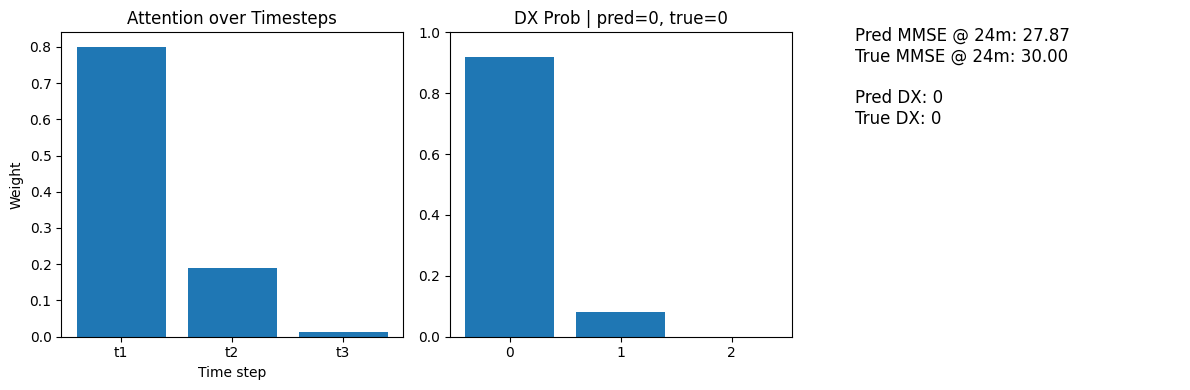

In [9]:
# =========================================
# 11) Quick visualization (automatically save high-res PNG to figures/)
# =========================================
import os
import matplotlib.pyplot as plt
import torch.nn.functional as Fnn
import random

# Create save directory
SAVE_DIR = "figures"
os.makedirs(SAVE_DIR, exist_ok=True)

def extract_attn_weights_from_x(model, xb):
    """Extract attention weights from the model given input xb."""
    model.eval()
    with torch.no_grad():
        out, _ = model.lstm(xb)
        e = model.attn(out)
        w = torch.softmax(e, dim=1)
    return w.squeeze(0).squeeze(-1).cpu().numpy()

def visualize_from_loader(loader, num_samples=3, seed=42, save_prefix="sample"):
    """
    Randomly select samples from a DataLoader, visualize:
    - Attention weights over time steps
    - Classification probabilities
    - Predicted vs. true MMSE and DX
    Save each plot as a high-resolution PNG.
    """
    random.seed(seed)
    model.eval()
    xb_all, yreg_all, ycls_all = next(iter(loader))
    B, T, Fdim = xb_all.shape
    idxs = random.sample(range(B), k=min(num_samples, B))
    for idx_plot, i in enumerate(idxs, start=1):
        xb = xb_all[i:i+1].to(device)
        yreg_true = float(yreg_all[i].item())
        ycls_true = int(ycls_all[i].item())
        with torch.no_grad():
            y_reg, y_cls = model(xb)
            mmse_pred = float(y_reg.squeeze(0).cpu().numpy())
            probs = Fnn.softmax(y_cls, dim=1).squeeze(0).cpu().numpy()
            pred_idx = int(probs.argmax())
            pred_label = idx_to_dx.get(pred_idx, pred_idx)
            true_label = idx_to_dx.get(ycls_true, ycls_true)
        attn_w = extract_attn_weights_from_x(model, xb)

        plt.figure(figsize=(12,4))
        # Attention weights
        plt.subplot(1,3,1)
        plt.bar([f"t{t}" for t in range(1, T+1)], attn_w)
        plt.title("Attention over Timesteps")
        plt.xlabel("Time step")
        plt.ylabel("Weight")
        # Classification probabilities
        plt.subplot(1,3,2)
        cls_labels = [idx_to_dx[i] if i in idx_to_dx else i for i in range(len(probs))]
        plt.bar([str(c) for c in cls_labels], probs)
        plt.ylim(0,1)
        plt.title(f"DX Prob | pred={pred_label}, true={true_label}")
        # Text info
        plt.subplot(1,3,3)
        plt.axis('off')
        text = (f"Pred MMSE @ {GRID[-1]}m: {mmse_pred:.2f}\n"
                f"True MMSE @ {GRID[-1]}m: {yreg_true:.2f}\n\n"
                f"Pred DX: {pred_label}\nTrue DX: {true_label}")
        plt.text(0.05, 0.7, text, fontsize=12)
        plt.tight_layout()

        # Save high-res PNG
        save_path = os.path.join(SAVE_DIR, f"{save_prefix}_{idx_plot}.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"[Saved] {save_path}")
        plt.show()

# — Usage example
visualize_from_loader(test_loader, num_samples=1, save_prefix="test_sample")


[Saved] figures\patient_6_forecast_en.png


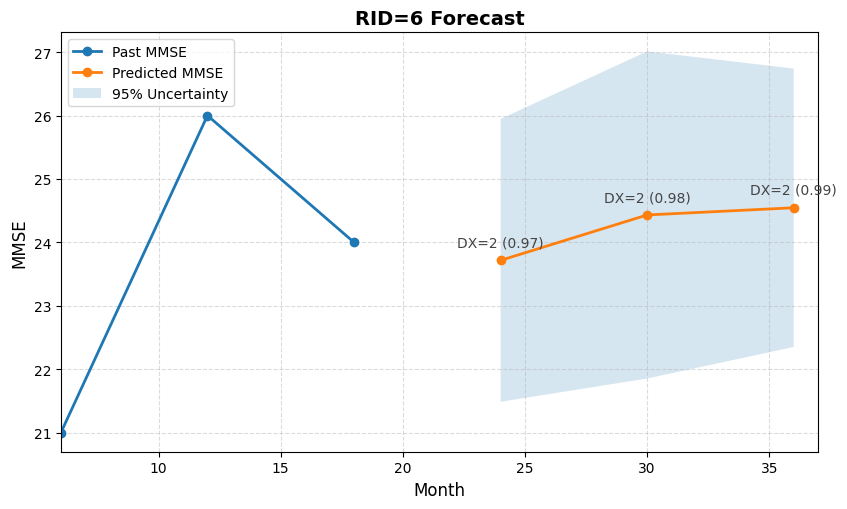

In [10]:
# =========================================
# Enhanced version: Individual future forecast visualization 
# (Auto Chinese font support + auto save high-resolution figure)
# Saved to figures/ directory
# =========================================
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
import torch

# -----------------------------
# Sanity check for dependencies
# -----------------------------
def _assert_context_ready():
    required = [
        "df","GRID","dynamic_in_cols","static_cols_auto",
        "TARGET_MMSE","TARGET_DX","col_medians","scaler",
        "device","model","idx_to_dx"
    ]
    missing = [k for k in required if k not in globals()]
    assert len(missing) == 0, f"Missing required globals: {missing}. Make sure you have run the training/prepare cells."

_assert_context_ready()

# Create directory for saving figures
SAVE_DIR = "figures"
os.makedirs(SAVE_DIR, exist_ok=True)

def _set_chinese_font(auto=True, prefer=("Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans CN")):
    """
    Automatically set an available Chinese font to avoid boxes for Chinese text.
    Safe to keep even if you only output English.
    """
    plt.rcParams['axes.unicode_minus'] = False
    if not auto:
        return
    installed = set(f.name for f in font_manager.fontManager.ttflist)
    for name in prefer:
        if name in installed:
            plt.rcParams['font.sans-serif'] = [name]
            return

# ------- helpers reused here (standalone) -------
def _fillna_with_median(X, med):
    """
    Fill NaNs in a 3D array [N, T, F] using provided per-column medians (1D of length F).
    """
    X2 = X.reshape(-1, X.shape[-1])
    med2 = np.where(np.isnan(med), 0.0, med)  # fallback to 0 if a column's median is NaN
    nan_mask = np.isnan(X2)
    if nan_mask.any():
        cols = np.where(nan_mask.any(axis=0))[0]
        for j in cols:
            X2[nan_mask[:, j], j] = med2[j]
    return X2.reshape(X.shape)

def _build_window_for_subject(df, rid, grid, dynamic_in_cols, static_cols, target_mmse, target_dx):
    """
    Build the full grid window [T, F_in] for a subject (no train scaling here),
    and return the merged (interpolated) dataframe for plotting true/interpolated MMSE.
    - Dynamics + MMSE are linearly interpolated on the grid.
    - DX is NOT interpolated (only used elsewhere for labels if needed).
    """
    sub_df = df[df["RID"] == rid].copy()
    assert len(sub_df) > 0, f"RID={rid} not found in df"

    # sort & aggregate duplicate months by mean (numeric only)
    sub_df_sorted = sub_df.sort_values("Month")
    sub_num = sub_df_sorted.set_index("Month").groupby(level=0).mean(numeric_only=True)

    # static vector from first row (if any)
    if len(static_cols) > 0:
        stat_vec = sub_df_sorted.iloc[0][static_cols].values.astype(float)
    else:
        stat_vec = np.zeros((0,), dtype=float)

    # align to grid
    grid_df = pd.DataFrame({"Month": grid}).set_index("Month")
    merged = grid_df.join(sub_num[dynamic_in_cols + [target_mmse, target_dx]])

    # is_obs flag: whether all dynamic inputs are present at that grid time
    is_obs = (~merged[dynamic_in_cols].isna().any(axis=1)).astype(int).values.reshape(-1, 1)

    # interpolate dynamics + MMSE (DX untouched)
    merged_interp = merged.copy()
    merged_interp[dynamic_in_cols + [target_mmse]] = merged[dynamic_in_cols + [target_mmse]] \
        .interpolate(method='linear', limit_direction='both')

    # delta months since last real dynamic observation
    real_months_dyn = sub_num.index.values.tolist()
    last_real = None
    delta_m = []
    for t in grid:
        if t in real_months_dyn:
            delta_m.append(0); last_real = t
        else:
            delta_m.append(0 if last_real is None else (t - last_real))
    delta_m = np.array(delta_m, dtype=float).reshape(-1, 1)

    # absolute month
    abs_m = np.array(grid, dtype=float).reshape(-1, 1)

    # assemble input [T, F_in]: dynamics(interpolated) + statics + is_obs + delta_m + abs_month
    dyn = merged_interp[dynamic_in_cols].values
    stat_block = np.repeat(stat_vec.reshape(1, -1), len(grid), axis=0)
    X_full = np.hstack([dyn, stat_block, is_obs, delta_m, abs_m]).astype(np.float32)

    return X_full, merged_interp

def _enable_dropout(m):
    """
    Enable dropout layers during inference for MC sampling.
    """
    for module in m.modules():
        if isinstance(module, torch.nn.Dropout):
            module.train()

@torch.no_grad()
def _mc_predict(model, xb, mc_runs=200):
    """
    Monte Carlo dropout predictions.
    Returns:
      reg_mean [B], reg_std [B],
      cls_prob_mean [B, C]
    """
    if mc_runs <= 1:
        model.eval()
        y_reg, y_cls = model(xb)
        reg_mean = y_reg.squeeze(-1).cpu().numpy()
        reg_std = np.zeros_like(reg_mean, dtype=np.float32)
        cls_prob = torch.softmax(y_cls, dim=1).cpu().numpy()
        return reg_mean, reg_std, cls_prob

    # collect samples
    reg_samples = []
    cls_prob_samples = []

    for _ in range(mc_runs):
        model.eval()
        _enable_dropout(model)  # turn on dropout only
        y_reg, y_cls = model(xb)
        reg_samples.append(y_reg.squeeze(-1).cpu().numpy())             # [B]
        cls_prob_samples.append(torch.softmax(y_cls, dim=1).cpu().numpy())  # [B, C]

    reg_samples = np.stack(reg_samples, axis=0)         # [mc, B]
    cls_prob_samples = np.stack(cls_prob_samples, axis=0)  # [mc, B, C]

    reg_mean = reg_samples.mean(axis=0)                 # [B]
    reg_std  = reg_samples.std(axis=0)                  # [B]
    cls_prob = cls_prob_samples.mean(axis=0)            # [B, C]
    return reg_mean, reg_std, cls_prob

# ---------------- main plotting function ----------------
def plot_patient_forecast_pretty(
    rid,
    horizons=[6, 12],
    mc_runs=200,
    lang="en",                # keep param for compatibility; output is English labels below
    line_width=2,
    alpha_band=0.18
):
    """
    Show in one plot: historical MMSE, future (+6/+12...) predictions,
    95% uncertainty band (MC dropout), and annotate each future point with DX=label(probability).
    """
    # Optional: enable Chinese font when lang == "zh"
    _set_chinese_font(auto=(lang=="zh"))

    # Fixed English labels (simpler/cleaner)
    lbl_past   = "Past MMSE"
    lbl_pred   = "Predicted MMSE"
    lbl_band   = "95% Uncertainty"
    xlabel_txt = "Month"
    title_txt  = f"RID={rid} Forecast"
    dx_fmt     = (lambda dx,p: f"DX={dx} ({p:.2f})")

    # Build subject window on the 6/12/18/24 grid
    X_full, merged_interp = _build_window_for_subject(
        df, rid, GRID, dynamic_in_cols, static_cols_auto, TARGET_MMSE, TARGET_DX
    )
    # historical points are first 3 steps (6/12/18)
    hist_months = [GRID[0], GRID[1], GRID[2]]
    hist_mmse   = merged_interp[TARGET_MMSE].values[:3].astype(float).tolist()

    # First 3-step input window (6/12/18), then scale using training scaler
    X3 = _fillna_with_median(X_full[:3, :][None, ...], col_medians)
    N,T,Fdim = X3.shape
    X3 = scaler.transform(X3.reshape(N*T, Fdim)).reshape(N,T,Fdim)
    xb = torch.tensor(X3, dtype=torch.float32, device=device)

    # Roll-forward predictions in 6-month steps up to requested horizons
    grid_idx = 2
    last_month = GRID[2]
    fut_months, fut_mean, fut_std, fut_dx_label, fut_dx_prob = [], [], [], [], []

    for h in horizons:
        steps = int(h // 6)
        for _ in range(steps):
            reg_m, reg_s, cls_m = _mc_predict(model, xb, mc_runs=mc_runs)
            mmse_m = float(np.ravel(reg_m)[0]); mmse_s = float(np.ravel(reg_s)[0])
            c_idx = int(np.argmax(cls_m[0]))
            dx_label = idx_to_dx[c_idx]; dx_prob = float(cls_m[0, c_idx])

            next_month = last_month + 6
            fut_months.append(next_month); fut_mean.append(mmse_m); fut_std.append(mmse_s)
            fut_dx_label.append(dx_label); fut_dx_prob.append(dx_prob)

            # slide the 3-step window forward by 1 step
            start_idx = max(0, grid_idx - 1)
            X_next3 = X_full[start_idx+1:start_idx+4, :]
            if X_next3.shape[0] < 3:
                last_row = X_full[-1:, :]
                X_next3 = np.vstack([X_next3, np.repeat(last_row, 3 - X_next3.shape[0], axis=0)])
            X_next3 = _fillna_with_median(X_next3[None, ...], col_medians)
            N2,T2,F2 = X_next3.shape
            X_next3 = scaler.transform(X_next3.reshape(N2*T2, F2)).reshape(N2,T2,F2)
            xb = torch.tensor(X_next3, dtype=torch.float32, device=device)

            grid_idx = min(grid_idx + 1, len(GRID)-1)
            last_month = next_month

    # ----- Plot -----
    fig, ax = plt.subplots(figsize=(8.6, 5.2))
    ax.plot(hist_months, hist_mmse, marker='o', linewidth=line_width, label=lbl_past)
    ax.plot(fut_months, fut_mean, marker='o', linewidth=line_width, label=lbl_pred)

    lo = [m - 1.96*s for m,s in zip(fut_mean, fut_std)]
    hi = [m + 1.96*s for m,s in zip(fut_mean, fut_std)]
    ax.fill_between(fut_months, lo, hi, alpha=alpha_band, label=lbl_band)

    # annotate DX=label(prob)
    for x, y, dx, p in zip(fut_months, fut_mean, fut_dx_label, fut_dx_prob):
        ax.annotate(dx_fmt(dx, p), xy=(x, y), xytext=(0, 10),
                    textcoords='offset points', ha='center', fontsize=10, color='#444')

    ax.set_xlabel(xlabel_txt, fontsize=12)
    ax.set_ylabel('MMSE', fontsize=12)
    ax.set_title(title_txt, fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.45)
    ax.set_xlim(min(hist_months), max(fut_months) + 1)
    ax.legend(frameon=True)
    plt.tight_layout()

    # Save high-resolution image
    save_path = os.path.join(SAVE_DIR, f"patient_{rid}_forecast_{lang}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"[Saved] {save_path}")
    plt.show()

# -------- Example usage (auto-save to figures/) --------
plot_patient_forecast_pretty(rid=6, horizons=[6,12], mc_runs=200, lang="en")


[Test] RMSE=2.748  MAE=2.034  |  ACC=0.799  F1(macro)=0.796  AUC(macro)=0.926  AUC(micro)=0.937
[Saved] figures\diagnostics_residuals.png


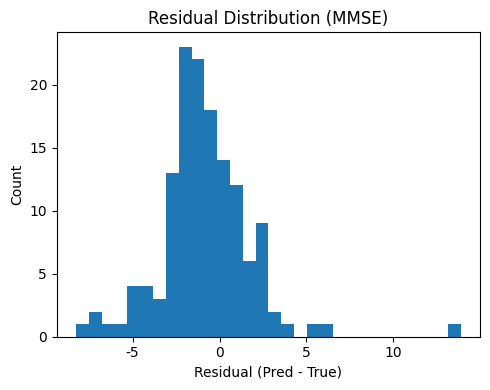

[Saved] figures\diagnostics_roc.png


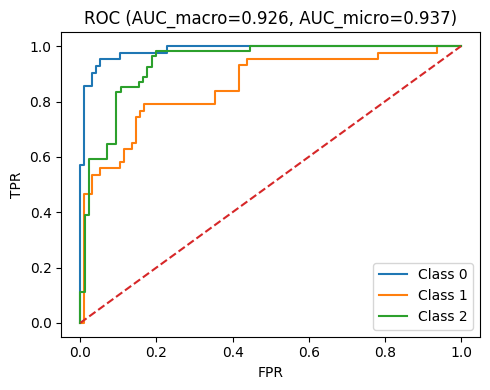

[Saved] figures\diagnostics_confusion.png


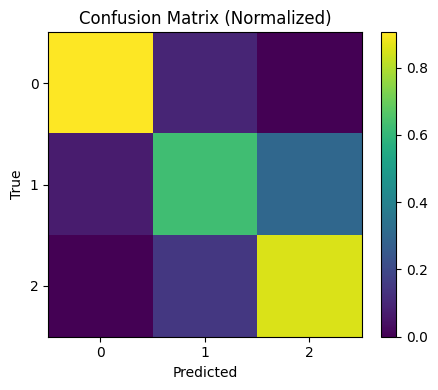

In [11]:
# =========================================
# 13-lite) Lightweight diagnostics: AUC + Residuals + (Optional) Confusion Matrix
# Automatically save high-resolution images to figures/ directory
# =========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import (confusion_matrix, f1_score, roc_auc_score,
                             roc_curve)

# Automatically create save directory
SAVE_DIR = "figures"
os.makedirs(SAVE_DIR, exist_ok=True)

@torch.no_grad()
def _gather_preds(model, loader):
    """Collect predictions and labels from the model over the given DataLoader."""
    model.eval()
    y_r_true, y_r_pred = [], []
    y_c_true, y_c_prob = [], []
    for xb, yb_reg, yb_cls in loader:
        xb = xb.to(device)
        y_reg, y_cls = model(xb)
        y_r_true.append(yb_reg.numpy())
        y_r_pred.append(y_reg.cpu().numpy())
        y_c_true.append(yb_cls.numpy())
        y_c_prob.append(torch.softmax(y_cls, dim=1).cpu().numpy())
    y_r_true = np.concatenate(y_r_true)
    y_r_pred = np.concatenate(y_r_pred)
    y_c_true = np.concatenate(y_c_true).astype(int)
    y_c_prob = np.concatenate(y_c_prob, axis=0)
    y_c_pred = y_c_prob.argmax(axis=1)
    return y_r_true, y_r_pred, y_c_true, y_c_pred, y_c_prob

def diagnostics_lite(loader, show_confusion=True):
    """Run lightweight diagnostics: RMSE, MAE, ACC, F1, AUC, residual distribution, ROC, and optionally confusion matrix."""
    y_t, y_p, yc_t, yc_pred, yc_prob = _gather_preds(model, loader)

    # Numerical metrics
    rmse = float(np.sqrt(np.mean((y_t - y_p)**2)))
    mae  = float(np.mean(np.abs(y_t - y_p)))
    acc  = float((yc_t == yc_pred).mean())
    f1_macro = float(f1_score(yc_t, yc_pred, average='macro'))
    y_true_ovr = np.eye(yc_prob.shape[1])[yc_t]
    try:
        auc_macro = float(roc_auc_score(y_true_ovr, yc_prob, average='macro', multi_class='ovr'))
        auc_micro = float(roc_auc_score(y_true_ovr, yc_prob, average='micro', multi_class='ovr'))
    except Exception:
        auc_macro, auc_micro = float('nan'), float('nan')

    print(f"[Test] RMSE={rmse:.3f}  MAE={mae:.3f}  |  ACC={acc:.3f}  F1(macro)={f1_macro:.3f}  "
          f"AUC(macro)={auc_macro:.3f}  AUC(micro)={auc_micro:.3f}")

    # Residual distribution
    residuals = y_p - y_t
    plt.figure(figsize=(5,4))
    plt.hist(residuals, bins=30)
    plt.xlabel("Residual (Pred - True)")
    plt.ylabel("Count")
    plt.title("Residual Distribution (MMSE)")
    plt.tight_layout()
    save_path_res = os.path.join(SAVE_DIR, "diagnostics_residuals.png")
    plt.savefig(save_path_res, dpi=300, bbox_inches='tight')
    print(f"[Saved] {save_path_res}")
    plt.show()

    # Multi-class ROC (OvR)
    plt.figure(figsize=(5,4))
    for i in range(yc_prob.shape[1]):
        fpr, tpr, _ = roc_curve(y_true_ovr[:, i], yc_prob[:, i])
        plt.plot(fpr, tpr, label=f"Class {idx_to_dx[i]}")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(f"ROC (AUC_macro={auc_macro:.3f}, AUC_micro={auc_micro:.3f})")
    plt.legend()
    plt.tight_layout()
    save_path_roc = os.path.join(SAVE_DIR, "diagnostics_roc.png")
    plt.savefig(save_path_roc, dpi=300, bbox_inches='tight')
    print(f"[Saved] {save_path_roc}")
    plt.show()

    # Optional confusion matrix
    if show_confusion:
        cm = confusion_matrix(yc_t, yc_pred, labels=list(range(yc_prob.shape[1])))
        cm = cm / cm.sum(axis=1, keepdims=True)
        plt.figure(figsize=(4.6,4))
        plt.imshow(cm, aspect='auto')
        plt.xticks(range(yc_prob.shape[1]), [idx_to_dx[i] for i in range(yc_prob.shape[1])])
        plt.yticks(range(yc_prob.shape[1]), [idx_to_dx[i] for i in range(yc_prob.shape[1])])
        plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Normalized)")
        plt.colorbar()
        plt.tight_layout()
        save_path_cm = os.path.join(SAVE_DIR, "diagnostics_confusion.png")
        plt.savefig(save_path_cm, dpi=300, bbox_inches='tight')
        print(f"[Saved] {save_path_cm}")
        plt.show()

# Example usage (automatically saves to figures/)
diagnostics_lite(test_loader, show_confusion=True)


In [13]:
# ===== LSTM unified evaluation: RMSE, MAE, Accuracy, Macro-F1, AUC(ovr) with 95% CI =====
import numpy as np
import torch
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             accuracy_score, f1_score, roc_auc_score)

# ---------- 1) Collect test predictions & targets ----------
model.eval()
mmse_true_list, mmse_pred_list = [], []
dx_true_list, dx_pred_list, dx_prob_list = [], [], []

with torch.no_grad():
    for xb, yb_reg, yb_cls in test_loader:
        xb = xb.to(device)
        yb_reg = yb_reg.to(device)
        yb_cls = yb_cls.to(device)

        pr_reg, pr_cls = model(xb)                 # pr_reg: [B], pr_cls: [B, C]
        probs = torch.softmax(pr_cls, dim=1)       # convert logits -> probabilities

        mmse_true_list.append(yb_reg.cpu().numpy())
        mmse_pred_list.append(pr_reg.cpu().numpy())
        dx_true_list.append(yb_cls.cpu().numpy())
        dx_pred_list.append(pr_cls.argmax(dim=1).cpu().numpy())
        dx_prob_list.append(probs.cpu().numpy())

# Make arrays 
y_mmse_test_raw_lstm   = np.concatenate(mmse_true_list)
y_test_mmse_pred_lstm  = np.concatenate(mmse_pred_list)
y_dx_test_enc_lstm     = np.concatenate(dx_true_list).astype(int)
y_test_dx_pred_lstm    = np.concatenate(dx_pred_list).astype(int)
y_prob_dx_lstm         = np.concatenate(dx_prob_list)

# ---------- 2) Helpers ----------
def _rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def _bootstrap_metric(metric_fn, y_true, y_pred_or_prob, n_boot=1000, seed=42):
    """
    Bootstrap a metric to estimate mean, std, and 95% CI.
    metric_fn: callable(y_true, y_pred_or_prob) -> float
    y_pred_or_prob can be shape (n,) or (n, C)
    """
    rng = np.random.RandomState(seed)
    n = len(y_true)
    vals = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yt = y_true[idx]
        yp = y_pred_or_prob[idx] if y_pred_or_prob.ndim == 1 else y_pred_or_prob[idx, :]
        try:
            vals.append(metric_fn(yt, yp))
        except ValueError:
            # e.g., multiclass AUC fails if a bootstrap sample contains < 2 classes
            continue
    vals = np.asarray(vals, dtype=float)
    mean = float(np.mean(vals))
    std  = float(np.std(vals))
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return mean, std, (float(lo), float(hi))

def _fmt(name, point, mean, std, ci):
    lo, hi = ci
    print(f"{name}: {point:.3f}  |  {mean:.3f} ± {std:.3f}  (95% CI {lo:.3f}–{hi:.3f})")

# ---------- 3) Point estimates ----------
rmse_point = _rmse(y_mmse_test_raw_lstm, y_test_mmse_pred_lstm)
mae_point  = mean_absolute_error(y_mmse_test_raw_lstm, y_test_mmse_pred_lstm)
acc_point  = accuracy_score(y_dx_test_enc_lstm, y_test_dx_pred_lstm)
f1_point   = f1_score(y_dx_test_enc_lstm, y_test_dx_pred_lstm, average="macro")
auc_point  = roc_auc_score(y_dx_test_enc_lstm, y_prob_dx_lstm, multi_class="ovr", average="macro")

# ---------- 4) Bootstrap 95% CIs ----------
rmse_mean, rmse_std, rmse_ci = _bootstrap_metric(lambda yt, yp: _rmse(yt, yp),
                                                 y_mmse_test_raw_lstm, y_test_mmse_pred_lstm)
mae_mean,  mae_std,  mae_ci  = _bootstrap_metric(mean_absolute_error,
                                                 y_mmse_test_raw_lstm, y_test_mmse_pred_lstm)
acc_mean,  acc_std,  acc_ci  = _bootstrap_metric(accuracy_score,
                                                 y_dx_test_enc_lstm, y_test_dx_pred_lstm)
f1_mean,   f1_std,   f1_ci   = _bootstrap_metric(lambda yt, yp: f1_score(yt, yp, average="macro"),
                                                 y_dx_test_enc_lstm, y_test_dx_pred_lstm)
auc_mean,  auc_std,  auc_ci  = _bootstrap_metric(lambda yt, yp: roc_auc_score(yt, yp, multi_class="ovr", average="macro"),
                                                 y_dx_test_enc_lstm, y_prob_dx_lstm)

# ---------- 5) Pretty print ----------
print("\n[TEST - Unified Metrics with 95% CIs (BiLSTM-Attention)]")
_fmt("RMSE",     rmse_point, rmse_mean, rmse_std, rmse_ci)
_fmt("MAE",      mae_point,  mae_mean,  mae_std,  mae_ci)
_fmt("Accuracy", acc_point,  acc_mean,  acc_std,  acc_ci)
_fmt("Macro-F1", f1_point,   f1_mean,   f1_std,   f1_ci)
_fmt("AUC(ovr)", auc_point,  auc_mean,  auc_std,  auc_ci)

# ---------- 6) Markdown rows for your Table 4.x (copy-paste to the thesis) ----------
row_reg = (
    f"| BiLSTM-Attention | Regression | "
    f"RMSE {rmse_point:.3f} (95% {rmse_ci[0]:.3f}–{rmse_ci[1]:.3f}), "
    f"MAE {mae_point:.3f} (95% {mae_ci[0]:.3f}–{mae_ci[1]:.3f}) |"
)
row_cls = (
    f"| BiLSTM-Attention | Classification | "
    f"ACC {acc_point:.3f} (95% {acc_ci[0]:.3f}–{acc_ci[1]:.3f}), "
    f"AUC {auc_point:.3f} (95% {auc_ci[0]:.3f}–{auc_ci[1]:.3f}), "
    f"Macro-F1 {f1_point:.3f} (95% {f1_ci[0]:.3f}–{f1_ci[1]:.3f}) |"
)

print("\nMarkdown rows for Table 4.x:\n")
print(row_reg)
print(row_cls)



[TEST - Unified Metrics with 95% CIs (BiLSTM-Attention)]
RMSE: 2.748  |  2.743 ± 0.295  (95% CI 2.209–3.343)
MAE: 2.034  |  2.035 ± 0.160  (95% CI 1.738–2.349)
Accuracy: 0.799  |  0.797 ± 0.033  (95% CI 0.734–0.856)
Macro-F1: 0.796  |  0.793 ± 0.033  (95% CI 0.730–0.855)
AUC(ovr): 0.926  |  0.925 ± 0.018  (95% CI 0.886–0.958)

Markdown rows for Table 4.x:

| BiLSTM-Attention | Regression | RMSE 2.748 (95% 2.209–3.343), MAE 2.034 (95% 1.738–2.349) |
| BiLSTM-Attention | Classification | ACC 0.799 (95% 0.734–0.856), AUC 0.926 (95% 0.886–0.958), Macro-F1 0.796 (95% 0.730–0.855) |


In [16]:
# =========================================
# 0) Environment & Random Seed
# =========================================
import os, random, math, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# =========================================
# 1) Parameter section (modify as needed)
# =========================================
CSV_PATH     = r""
ID_COL       = "RID"
TIME_COL     = "Month"

TARGET_MMSE  = "MMSE"   # Regression target
TARGET_DX    = "DX"     # Classification target (encoded as 0/1/2)

# Many subjects start at month 6 → use 6/12/18/24
GRID         = [6, 12, 18, 24]
MIN_REAL_POINTS = 2       # Require at least 2 real months of dynamic inputs

BATCH_SIZE = 64
LR         = 6e-4
EPOCHS     = 300
PATIENCE   = 40

HIDDEN     = 256
N_LAYERS   = 2
DROPOUT    = 0.25  # If you need to re-balance toward regression, try 0.20

LAMBDA_REG = 1.0
LAMBDA_CLS = 1.8   # Slightly pull back classification weight to favor regression

USE_WEIGHTED_SAMPLER = False  # Avoid stacking resampling + class weighting/focal

MODEL_SAVE = "best_lstm_6_12_18_24.pt"

# =========================================
# 2) Load Data & Auto-detect Static/Dynamic Features
# =========================================
df = pd.read_csv(CSV_PATH)
assert ID_COL in df.columns and TIME_COL in df.columns, "ID or Month column not found"
assert TARGET_MMSE in df.columns, f"Target column {TARGET_MMSE} not found"
assert TARGET_DX   in df.columns, f"Target column {TARGET_DX} not found"

# Numeric columns only
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Candidate input features: remove ID/TIME/targets
candidate_cols = [c for c in num_cols if c not in [ID_COL, TIME_COL, TARGET_MMSE, TARGET_DX]]

# Auto-detect static/dynamic (variance=0 within each RID → static)
var_zero_ratio = {}
for c in candidate_cols:
    v = df.groupby(ID_COL)[c].var().fillna(0.0)
    var_zero_ratio[c] = (v == 0).mean()

STATIC_THRESHOLD = 0.8
static_cols_auto  = [c for c, r in var_zero_ratio.items() if r >= STATIC_THRESHOLD]
dynamic_cols_auto = [c for c in candidate_cols if c not in static_cols_auto]

# Optional: remove "config-like" columns from statics (e.g., starting with BASETP)
ban_statics = [c for c in static_cols_auto if str(c).upper().startswith("BASETP")]
static_cols_auto = [c for c in static_cols_auto if c not in ban_statics]

# Dynamic input features, additionally excluding leakage columns
leak_cols = {TARGET_MMSE, TARGET_DX}
dynamic_in_cols = [c for c in dynamic_cols_auto if c not in leak_cols]

print(f"Auto-detected static features (first 10): {static_cols_auto[:10]}  ... total {len(static_cols_auto)}")
print(f"Auto-detected dynamic features (first 10): {dynamic_in_cols[:10]}  ... total {len(dynamic_in_cols)}")

# DX label mapping (ensure int categories 0/1/2...)
dx_series_num = pd.to_numeric(df[TARGET_DX], errors='coerce')
dx_unique = sorted(dx_series_num.dropna().unique().tolist())
num_classes = len(dx_unique)
dx_to_idx = {int(v): i for i, v in enumerate(dx_unique)}
idx_to_dx = {i: int(v) for i, v in enumerate(dx_unique)}
print("DX label mapping:", dx_to_idx)

# =========================================
# 3) Build Samples: align grid + interpolate + time aux features
#    (use 6/12/18 as input, predict 24)
# =========================================
def choose_dx_label_at_24(sub_df_num):
    """Select the DX label at month 24 without interpolation; if missing, pick the nearest real label (prefer <= 24)."""
    if TARGET_DX not in sub_df_num.columns:
        return None
    dx_series = sub_df_num[TARGET_DX]
    if dx_series.isna().all():
        return None
    if 24 in dx_series.index and not np.isnan(dx_series.loc[24]):
        return int(round(float(dx_series.loc[24])))
    real_months = dx_series.dropna().index.to_list()
    left  = [m for m in real_months if m <= 24]
    right = [m for m in real_months if m >= 24]
    cand = max(left) if len(left) > 0 else (min(right) if len(right) > 0 else None)
    if cand is None or np.isnan(dx_series.loc[cand]):
        return None
    return int(round(float(dx_series.loc[cand])))

def build_subject_tensor(sub_df, grid, dynamic_in_cols, static_cols, target_mmse, target_dx):
    """
    Align to a fixed grid (dynamic + MMSE: linear interpolation; DX: no interpolation).
    Concatenate: dyn + stat + is_obs + delta_m + abs_m
    Returns:
      X: [T, F_in], y_mmse (float, at month 24), y_dx_idx (int), ok (bool)
    """
    sub_df_sorted = sub_df.sort_values(TIME_COL)

    # Static features (first row)
    if len(static_cols) > 0:
        stat_vec = sub_df_sorted.iloc[0][static_cols].values.astype(float)
    else:
        stat_vec = np.zeros((0,), dtype=float)

    # Multiple rows in the same month → mean over numeric columns by month
    sub_num = sub_df_sorted.set_index(TIME_COL).groupby(level=0).mean(numeric_only=True)

    # Align grid
    grid_df = pd.DataFrame({TIME_COL: grid}).set_index(TIME_COL)
    merged = grid_df.join(sub_num[dynamic_in_cols + [target_mmse, target_dx]])

    # is_obs: whether all dynamic input columns are present at each grid time
    is_obs = (~merged[dynamic_in_cols].isna().any(axis=1)).astype(int).values.reshape(-1, 1)

    # Interpolate dynamics + MMSE (DX is NOT interpolated)
    merged_interp = merged.copy()
    merged_interp[dynamic_in_cols + [target_mmse]] = merged[dynamic_in_cols + [target_mmse]] \
        .interpolate(method='linear', limit_direction='both')

    # delta_months: months since the last real observation (based on original dynamic months in sub_num)
    real_months_dyn = sub_num.index.values.tolist()
    last_real = None
    delta_m = []
    for t in grid:
        if t in real_months_dyn:
            delta_m.append(0); last_real = t
        else:
            delta_m.append(0 if last_real is None else (t - last_real))
    delta_m = np.array(delta_m, dtype=float).reshape(-1, 1)

    # absolute month
    abs_m = np.array(grid, dtype=float).reshape(-1, 1)

    # Assemble input: dynamics (interpolated) + statics + is_obs + delta_m + abs_month
    dyn = merged_interp[dynamic_in_cols].values
    stat_block = np.repeat(stat_vec.reshape(1, -1), len(grid), axis=0)
    X = np.hstack([dyn, stat_block, is_obs, delta_m, abs_m])  # [T, F_in]

    # Target 1: MMSE (take interpolated value at month 24)
    y_mmse = float(merged_interp[target_mmse].iloc[-1])

    # Target 2: DX classification (no interpolation; select by rule)
    y_dx_val = choose_dx_label_at_24(sub_num)
    if y_dx_val is None or np.isnan(y_mmse):
        return None, None, None, False
    if int(y_dx_val) not in dx_to_idx:
        return None, None, None, False
    y_dx_idx = dx_to_idx[int(y_dx_val)]

    # Inclusion criterion: at least MIN_REAL_POINTS real dynamic months
    ok = (len(real_months_dyn) >= MIN_REAL_POINTS)
    return X, y_mmse, y_dx_idx, ok

# Build samples
Xs, y_mmse_list, y_dx_list, rids_kept = [], [], [], []
for rid, g in df.groupby(ID_COL):
    sub = g[[TIME_COL] + dynamic_in_cols + static_cols_auto + [TARGET_MMSE, TARGET_DX]]
    X_i, mmse_i, dx_i, ok = build_subject_tensor(sub, GRID, dynamic_in_cols, static_cols_auto,
                                                 TARGET_MMSE, TARGET_DX)
    if ok:
        Xs.append(X_i.astype(np.float32))
        y_mmse_list.append(float(mmse_i))
        y_dx_list.append(int(dx_i))
        rids_kept.append(rid)

Xs = np.stack(Xs)  # [N, 4, F_in]
y_mmse = np.array(y_mmse_list, dtype=float)   # [N]
y_dx   = np.array(y_dx_list,   dtype=int)     # [N]
print("Raw tensors:", Xs.shape, y_mmse.shape, y_dx.shape, "Kept subjects:", len(rids_kept))

# =========================================
# 4) Split dataset: 7:2:1 (stratified to keep class ratios)
# =========================================
def take_first_three_steps(X):  # Use first 3 steps (6/12/18) as input → predict 24
    return X[:, :3, :]

# First split: Train (70%) + Temp (30%)
X_train, X_temp, y_mmse_train, y_mmse_temp, y_dx_train, y_dx_temp = \
    train_test_split(Xs, y_mmse, y_dx, test_size=0.30, random_state=SEED, stratify=y_dx)

# Second split: Temp → Test (20%) + Val (10%)
X_test, X_val, y_mmse_test, y_mmse_val, y_dx_test, y_dx_val = \
    train_test_split(X_temp, y_mmse_temp, y_dx_temp, test_size=(1/3), random_state=SEED, stratify=y_dx_temp)

# Use only the first three steps as input
X_train_in = take_first_three_steps(X_train)
X_val_in   = take_first_three_steps(X_val)
X_test_in  = take_first_three_steps(X_test)

# Check class distribution
def show_class_dist(name, y):
    vals, cnts = np.unique(y, return_counts=True)
    print(name, dict(zip(vals, cnts)))
show_class_dist("train", y_dx_train)
show_class_dist("val",   y_dx_val)
show_class_dist("test",  y_dx_test)

# =========================================
# 5) Fill NaNs with training-column medians + standardize
# =========================================
Ntr, T_in, F_in = X_train_in.shape
train_2d = X_train_in.reshape(Ntr*T_in, F_in)
col_medians = np.nanmedian(train_2d, axis=0)

def fillna_with_median(X, med):
    """Fill NaNs in a 3D array [N, T, F] using provided per-column medians (1D of length F)."""
    X2 = X.reshape(-1, X.shape[-1])
    med2 = np.where(np.isnan(med), 0.0, med)  # fallback to 0 if a column's median is NaN
    nan_mask = np.isnan(X2)
    if nan_mask.any():
        cols = np.where(nan_mask.any(axis=0))[0]
        for j in cols:
            X2[nan_mask[:, j], j] = med2[j]
    return X2.reshape(X.shape)

# alias used by later blocks
_fillna_with_median = fillna_with_median

X_train_in = fillna_with_median(X_train_in, col_medians)
X_val_in   = fillna_with_median(X_val_in,   col_medians)
X_test_in  = fillna_with_median(X_test_in,  col_medians)

scaler = StandardScaler()
scaler.fit(X_train_in.reshape(-1, F_in))

def apply_scaler(X):
    N, T_in, F = X.shape
    X2 = scaler.transform(X.reshape(N*T_in, F))
    return X2.reshape(N, T_in, F)

X_train_in = apply_scaler(X_train_in)
X_val_in   = apply_scaler(X_val_in)
X_test_in  = apply_scaler(X_test_in)

# =========================================
# 6) Dataset & DataLoader (optional weighted sampling)
# =========================================
class MultiTaskSeqDataset(Dataset):
    def __init__(self, X, y_mmse, y_dx):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_mmse = torch.tensor(y_mmse, dtype=torch.float32)
        self.y_dx   = torch.tensor(y_dx,   dtype=torch.long)
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y_mmse[idx], self.y_dx[idx]

train_ds = MultiTaskSeqDataset(X_train_in, y_mmse_train, y_dx_train)
val_ds   = MultiTaskSeqDataset(X_val_in,   y_mmse_val,   y_dx_val)
test_ds  = MultiTaskSeqDataset(X_test_in,  y_mmse_test,  y_dx_test)

if USE_WEIGHTED_SAMPLER:
    class_counts = np.bincount(y_dx_train, minlength=num_classes)
    sample_weights = np.array([1.0 / (class_counts[c] + 1e-6) for c in y_dx_train], dtype=np.float32)
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
else:
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# =========================================
# 7) Multi-task LSTM model (bidirectional + attention + enhanced classifier head)
# =========================================
class LSTMMultiTask(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2, num_classes=3, bidirectional=True):
        super().__init__()
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=bidirectional
        )
        out_dim = hidden_size * (2 if bidirectional else 1)

        # Attention
        self.attn = nn.Sequential(
            nn.Linear(out_dim, out_dim // 2),
            nn.Tanh(),
            nn.Linear(out_dim // 2, 1)
        )
        self.shared_norm = nn.LayerNorm(out_dim)

        # Regression head
        self.reg_head = nn.Sequential(
            nn.Linear(out_dim, out_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim//2, 1)
        )
        # Classification head (enhanced)
        self.cls_head = nn.Sequential(
            nn.Linear(out_dim, out_dim),
            nn.ReLU(),
            nn.LayerNorm(out_dim),
            nn.Dropout(dropout),
            nn.Linear(out_dim, out_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim//2, num_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)       # [B, T, H*D]
        e = self.attn(out)          # [B, T, 1]
        w = torch.softmax(e, dim=1) # [B, T, 1]
        h = (w * out).sum(dim=1)    # [B, H*D]
        h = self.shared_norm(h)
        y_reg = self.reg_head(h).squeeze(-1)
        y_cls = self.cls_head(h)
        return y_reg, y_cls

model = LSTMMultiTask(F_in, HIDDEN, N_LAYERS, DROPOUT, num_classes=num_classes).to(device)

# ===== 7.x) EMA shadow weights (use EMA for validation/saving) =====
ema_decay = 0.997  # Smoother
ema_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

@torch.no_grad()
def ema_update():
    for k, v in model.state_dict().items():
        ema_state[k].mul_(ema_decay).add_(v.detach(), alpha=1 - ema_decay)

@torch.no_grad()
def load_ema_to_model():
    backup = {k: v.detach().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(ema_state, strict=True)
    return backup

@torch.no_grad()
def restore_model(backup):
    model.load_state_dict(backup, strict=True)

# =========================================
# 8) Loss / Optimizer / Scheduler / Evaluation (FocalLoss + joint early stopping)
# =========================================
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# Class weights (for analysis only; not fed into Focal directly to avoid double compensation)
class_counts = np.bincount(y_dx_train, minlength=num_classes)
class_weights = (class_counts.sum() / (class_counts + 1e-6))
class_weights = class_weights / class_weights.mean()
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(weight=alpha, reduction='none')
    def forward(self, logits, target):
        ce_i = self.ce(logits, target)  # [B]
        with torch.no_grad():
            pt = torch.softmax(logits, dim=1).gather(1, target.unsqueeze(1)).squeeze(1).clamp_min(1e-6)
        loss = ((1.0 - pt) ** self.gamma) * ce_i
        if self.reduction == 'mean': return loss.mean()
        if self.reduction == 'sum':  return loss.sum()
        return loss

# Regression loss: Huber (SmoothL1) — robust to outliers
loss_reg = nn.SmoothL1Loss(beta=0.5)
loss_cls = FocalLoss(alpha=None, gamma=1.0)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

def rmse_np(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred)**2))

def evaluate(loader):
    model.eval()
    mmse_true, mmse_pred = [], []
    dx_true, dx_pred = [], []
    with torch.no_grad():
        for xb, yb_reg, yb_cls in loader:
            xb = xb.to(device); yb_reg = yb_reg.to(device); yb_cls = yb_cls.to(device)
            pr_reg, pr_cls = model(xb)
            mmse_true.append(yb_reg.cpu().numpy())
            mmse_pred.append(pr_reg.cpu().numpy())
            dx_true.append(yb_cls.cpu().numpy())
            dx_pred.append(pr_cls.argmax(dim=1).cpu().numpy())
    mmse_true = np.concatenate(mmse_true)
    mmse_pred = np.concatenate(mmse_pred)
    dx_true   = np.concatenate(dx_true)
    dx_pred   = np.concatenate(dx_pred)
    rmse = rmse_np(mmse_true, mmse_pred)
    mae  = mean_absolute_error(mmse_true, mmse_pred)
    acc  = (dx_true == dx_pred).mean()
    return rmse, mae, acc

# Joint early-stopping metric (smaller is better); emphasize regression
TARGET_RMSE = 2.8
def ref_from_metrics(val_rmse, val_acc):
    rmse_norm = min(val_rmse / TARGET_RMSE, 3.0)
    return 0.6 * rmse_norm + 0.4 * (1.0 - val_acc)

# =========================================
# 9) Training (early stop on val, save best; use EMA weights for validation)
# =========================================
best_val = float('inf')
no_improve = 0

for epoch in range(1, EPOCHS+1):
    model.train()
    losses = []
    for xb, yb_reg, yb_cls in train_loader:
        xb = xb.to(device); yb_reg = yb_reg.to(device); yb_cls = yb_cls.to(device)
        optimizer.zero_grad()
        pr_reg, pr_cls = model(xb)
        l_reg = loss_reg(pr_reg, yb_reg)
        l_cls = loss_cls(pr_cls, yb_cls)
        loss = LAMBDA_REG*l_reg + LAMBDA_CLS*l_cls
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        ema_update()
        losses.append(loss.item())
    train_loss = float(np.mean(losses))

    # Validation (switch to EMA weights)
    backup = load_ema_to_model()
    val_rmse, val_mae, val_acc = evaluate(val_loader)
    ref_metric = ref_from_metrics(val_rmse, val_acc)
    scheduler.step(ref_metric)

    if ref_metric < best_val - 1e-6:
        best_val = ref_metric
        no_improve = 0
        ckpt = {
            "model_state": model.state_dict(),  # EMA weights snapshot
            "input_size": F_in,
            "grid": GRID,
            "dynamic_cols": dynamic_in_cols,
            "static_cols": static_cols_auto,
            "target_mmse": TARGET_MMSE,
            "target_dx": TARGET_DX,
            "dx_to_idx": {int(k): int(v) for k, v in dx_to_idx.items()},
            "idx_to_dx": {int(k): int(v) for k, v in idx_to_dx.items()},
            "num_classes": int(num_classes),
            "scaler_mean": scaler.mean_.astype(float).tolist(),
            "scaler_scale": scaler.scale_.astype(float).tolist(),
        }
        torch.save(ckpt, MODEL_SAVE)
    else:
        no_improve += 1

    # Restore original (non-EMA) weights for training
    restore_model(backup)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | trainLoss={train_loss:.4f} | "
              f"val RMSE={val_rmse:.3f} MAE={val_mae:.3f} ACC={val_acc:.3f} | ref={ref_metric:.4f}")

    if no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch}, best ref_metric={best_val:.4f}")
        break

# =========================================
# 10) Test set evaluation (load best weights)
# =========================================
ckpt = torch.load(MODEL_SAVE, map_location=device)
model.load_state_dict(ckpt["model_state"])
scaler.mean_  = np.array(ckpt["scaler_mean"],  dtype=float)
scaler.scale_ = np.array(ckpt["scaler_scale"], dtype=float)

test_rmse, test_mae, test_acc = evaluate(test_loader)
print(f"[Test] MMSE RMSE={test_rmse:.3f}  MAE={test_mae:.3f}  |  DX ACC={test_acc:.3f}")

# =========================================
# 11) Enhanced: Individual future forecast visualization
# =========================================
import matplotlib.pyplot as plt
from matplotlib import font_manager

def _assert_context_ready():
    required = [
        "df","GRID","dynamic_in_cols","static_cols_auto",
        "TARGET_MMSE","TARGET_DX","col_medians","scaler",
        "device","model","idx_to_dx", "ID_COL","TIME_COL"
    ]
    missing = [k for k in required if k not in globals()]
    assert len(missing) == 0, f"Missing required globals: {missing}. Make sure you have run the training/prepare cells."

_assert_context_ready()

# Create directory for saving figures
SAVE_DIR = "figures"
os.makedirs(SAVE_DIR, exist_ok=True)

def _set_chinese_font(auto=True, prefer=("Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans CN")):
    """Automatically set an available Chinese font to avoid boxes for Chinese text (safe to keep for English outputs)."""
    plt.rcParams['axes.unicode_minus'] = False
    if not auto:
        return
    installed = set(f.name for f in font_manager.fontManager.ttflist)
    for name in prefer:
        if name in installed:
            plt.rcParams['font.sans-serif'] = [name]
            return

def _build_window_for_subject(df, rid, grid, dynamic_in_cols, static_cols, target_mmse, target_dx):
    """
    Build the full grid window [T, F_in] for a subject (no train scaling here),
    and return the merged (interpolated) dataframe for plotting true/interpolated MMSE.
    - Dynamics + MMSE are linearly interpolated on the grid.
    - DX is NOT interpolated (only used elsewhere for labels if needed).
    """
    sub_df = df[df[ID_COL] == rid].copy()
    assert len(sub_df) > 0, f"{ID_COL}={rid} not found in df"

    sub_df_sorted = sub_df.sort_values(TIME_COL)
    sub_num = sub_df_sorted.set_index(TIME_COL).groupby(level=0).mean(numeric_only=True)

    # static vector from first row (if any)
    if len(static_cols) > 0:
        stat_vec = sub_df_sorted.iloc[0][static_cols].values.astype(float)
    else:
        stat_vec = np.zeros((0,), dtype=float)

    # align to grid
    grid_df = pd.DataFrame({TIME_COL: grid}).set_index(TIME_COL)
    merged = grid_df.join(sub_num[dynamic_in_cols + [target_mmse, target_dx]])

    # is_obs flag
    is_obs = (~merged[dynamic_in_cols].isna().any(axis=1)).astype(int).values.reshape(-1, 1)

    # interpolate dynamics + MMSE (DX untouched)
    merged_interp = merged.copy()
    merged_interp[dynamic_in_cols + [target_mmse]] = merged[dynamic_in_cols + [target_mmse]] \
        .interpolate(method='linear', limit_direction='both')

    # delta months since last real dynamic observation
    real_months_dyn = sub_num.index.values.tolist()
    last_real = None
    delta_m = []
    for t in grid:
        if t in real_months_dyn:
            delta_m.append(0); last_real = t
        else:
            delta_m.append(0 if last_real is None else (t - last_real))
    delta_m = np.array(delta_m, dtype=float).reshape(-1, 1)

    # absolute month
    abs_m = np.array(grid, dtype=float).reshape(-1, 1)

    # assemble input [T, F_in]: dynamics(interpolated) + statics + is_obs + delta_m + abs_month
    dyn = merged_interp[dynamic_in_cols].values
    stat_block = np.repeat(stat_vec.reshape(1, -1), len(grid), axis=0)
    X_full = np.hstack([dyn, stat_block, is_obs, delta_m, abs_m]).astype(np.float32)

    return X_full, merged_interp

def _enable_dropout(m):
    """Enable dropout layers during inference for MC sampling."""
    for module in m.modules():
        if isinstance(module, torch.nn.Dropout):
            module.train()

# ===== FIXED: robust _mc_predict to always return vectors =====
@torch.no_grad()
def _mc_predict(model, xb, mc_runs=200):
    """
    Monte Carlo dropout predictions.
    Returns:
      reg_mean [B], reg_std [B],
      cls_prob_mean [B, C]
    """
    B = xb.shape[0]

    if mc_runs <= 1:
        model.eval()
        y_reg, y_cls = model(xb)
        reg_mean = y_reg.detach().reshape(B).cpu().numpy()            # (B,)
        reg_std  = np.zeros(B, dtype=np.float32)                      # (B,)
        cls_prob = torch.softmax(y_cls, dim=1).detach().cpu().numpy() # (B,C)
        return reg_mean, reg_std, cls_prob

    reg_samples = []
    cls_prob_samples = []

    for _ in range(mc_runs):
        model.eval()
        _enable_dropout(model)  # turn on Dropout in heads during MC
        y_reg, y_cls = model(xb)
        reg_samples.append(y_reg.detach().reshape(B).cpu().numpy())            # (B,)
        cls_prob_samples.append(torch.softmax(y_cls, dim=1).detach().cpu().numpy())  # (B,C)

    reg_samples = np.stack(reg_samples, axis=0)         # (mc, B)
    cls_prob_samples = np.stack(cls_prob_samples, axis=0)  # (mc, B, C)

    reg_mean = reg_samples.mean(axis=0)                 # (B,)
    reg_std  = reg_samples.std(axis=0)                  # (B,)
    cls_prob = cls_prob_samples.mean(axis=0)            # (B,C)
    return reg_mean, reg_std, cls_prob

def plot_patient_forecast_pretty(
    rid,
    horizons=[6, 12],
    mc_runs=200,
    lang="en",                # keep param for compatibility; output is English labels below
    line_width=2,
    alpha_band=0.18
):
    """
    Show in one plot: historical MMSE, future (+6/+12...) predictions,
    95% uncertainty band (MC dropout), and annotate each future point with DX=label(probability).
    """
    _set_chinese_font(auto=(lang=="zh"))

    lbl_past   = "Past MMSE"
    lbl_pred   = "Predicted MMSE"
    lbl_band   = "95% Uncertainty"
    xlabel_txt = "Month"
    title_txt  = f"{ID_COL}={rid} Forecast"
    dx_fmt     = (lambda dx,p: f"DX={dx} ({p:.2f})")

    # Build subject window on the 6/12/18/24 grid
    X_full, merged_interp = _build_window_for_subject(
        df, rid, GRID, dynamic_in_cols, static_cols_auto, TARGET_MMSE, TARGET_DX
    )
    # historical points are first 3 steps (6/12/18)
    hist_months = [GRID[0], GRID[1], GRID[2]]
    hist_mmse   = merged_interp[TARGET_MMSE].values[:3].astype(float).tolist()

    # First 3-step input window (6/12/18), then scale using training scaler
    X3 = _fillna_with_median(X_full[:3, :][None, ...], col_medians)
    N,T,Fdim = X3.shape
    X3 = scaler.transform(X3.reshape(N*T, Fdim)).reshape(N,T,Fdim)
    xb = torch.tensor(X3, dtype=torch.float32, device=device)

    # Roll-forward predictions in 6-month steps up to requested horizons
    grid_idx = 2
    last_month = GRID[2]
    fut_months, fut_mean, fut_std, fut_dx_label, fut_dx_prob = [], [], [], [], []

    for h in horizons:
        steps = int(h // 6)
        for _ in range(steps):
            reg_m, reg_s, cls_m = _mc_predict(model, xb, mc_runs=mc_runs)
            mmse_m = float(np.ravel(reg_m)[0])  # FIXED robust indexing
            mmse_s = float(np.ravel(reg_s)[0])
            c_idx  = int(np.argmax(np.asarray(cls_m)[0]))
            dx_label = idx_to_dx[c_idx]; dx_prob = float(cls_m[0, c_idx])

            next_month = last_month + 6
            fut_months.append(next_month); fut_mean.append(mmse_m); fut_std.append(mmse_s)
            fut_dx_label.append(dx_label); fut_dx_prob.append(dx_prob)

            # slide the 3-step window forward by 1 step
            start_idx = max(0, grid_idx - 1)
            X_next3 = X_full[start_idx+1:start_idx+4, :]
            if X_next3.shape[0] < 3:
                last_row = X_full[-1:, :]
                X_next3 = np.vstack([X_next3, np.repeat(last_row, 3 - X_next3.shape[0], axis=0)])
            X_next3 = _fillna_with_median(X_next3[None, ...], col_medians)
            N2,T2,F2 = X_next3.shape
            X_next3 = scaler.transform(X_next3.reshape(N2*T2, F2)).reshape(N2,T2,F2)
            xb = torch.tensor(X_next3, dtype=torch.float32, device=device)

            grid_idx = min(grid_idx + 1, len(GRID)-1)
            last_month = next_month

    # ----- Plot -----
    fig, ax = plt.subplots(figsize=(8.6, 5.2))
    ax.plot(hist_months, hist_mmse, marker='o', linewidth=line_width, label=lbl_past)
    ax.plot(fut_months, fut_mean, marker='o', linewidth=line_width, label=lbl_pred)

    lo = [m - 1.96*s for m,s in zip(fut_mean, fut_std)]
    hi = [m + 1.96*s for m,s in zip(fut_mean, fut_std)]
    ax.fill_between(fut_months, lo, hi, alpha=alpha_band, label=lbl_band)

    # annotate DX=label(prob)
    for x, y, dx, p in zip(fut_months, fut_mean, fut_dx_label, fut_dx_prob):
        ax.annotate(dx_fmt(dx, p), xy=(x, y), xytext=(0, 10),
                    textcoords='offset points', ha='center', fontsize=10, color='#444')

    ax.set_xlabel(xlabel_txt, fontsize=12)
    ax.set_ylabel('MMSE', fontsize=12)
    ax.set_title(title_txt, fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.45)
    ax.set_xlim(min(hist_months), max(fut_months) + 1)
    ax.legend(frameon=True)
    plt.tight_layout()

    # Save high-resolution image
    save_path = os.path.join(SAVE_DIR, f"patient_{rid}_forecast_{lang}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"[Saved] {save_path}")
    plt.show()

# -------- Example usage (will save to figures/) --------
# plot_patient_forecast_pretty(rid=6, horizons=[6,12], mc_runs=200, lang="en")

# =========================================
# 12) Counterfactual & Sensitivity Experiments
# =========================================

def _assert_counterfactual_context():
    required = [
        "df","GRID","dynamic_in_cols","static_cols_auto",
        "TARGET_MMSE","TARGET_DX","col_medians","scaler",
        "device","model","idx_to_dx","dx_to_idx","rids_kept",
        "_build_window_for_subject","_mc_predict","ID_COL","TIME_COL"
    ]
    missing = [k for k in required if k not in globals()]
    assert not missing, f"Missing globals: {missing}"

_assert_counterfactual_context()

# ---- Rebuild RID splits mirroring earlier split (based on y_dx alignment with rids_kept) ----
rid_arr = np.array(rids_kept)
rid_train, rid_temp, ydx_train, ydx_temp = train_test_split(
    rid_arr, y_dx, test_size=0.30, random_state=SEED, stratify=y_dx
)
rid_test, rid_val, _, _ = train_test_split(
    rid_temp, ydx_temp, test_size=(1/3), random_state=SEED, stratify=ydx_temp
)
rid_test = np.asarray(rid_test)

# ---- Column pattern matching helpers ----
def find_columns_by_patterns(columns, patterns):
    """Return a list of column names whose lowercase contains any of the patterns."""
    out = []
    for c in columns:
        cl = str(c).lower()
        if any(p.lower() in cl for p in patterns):
            out.append(c)
    return out

COG_PATTERNS  = ["adas", "adas13", "cdrsb", "faq", "ravlt", "moca", "mmse"]
HIPP_PATTERNS = ["hipp", "hippocamp"]

def resolve_feature_sets():
    """Resolve cognitive and hippocampus feature columns (prefer dynamic, fallback to static)."""
    cog_dyn  = find_columns_by_patterns(dynamic_in_cols, COG_PATTERNS)
    cog_stat = find_columns_by_patterns(static_cols_auto, COG_PATTERNS)
    hip_dyn  = find_columns_by_patterns(dynamic_in_cols, HIPP_PATTERNS)
    hip_stat = find_columns_by_patterns(static_cols_auto, HIPP_PATTERNS)
    return {"cog_dyn": cog_dyn, "cog_stat": cog_stat, "hip_dyn": hip_dyn, "hip_stat": hip_stat}

FEATS = resolve_feature_sets()
print("[Resolved features]",
      "\n  cognitive (dyn):", FEATS["cog_dyn"],
      "\n  cognitive (stat):", FEATS["cog_stat"],
      "\n  hippocampus (dyn):", FEATS["hip_dyn"],
      "\n  hippocampus (stat):", FEATS["hip_stat"])

# ---- Apply perturbations on raw window X_full (before scaling) ----
def apply_perturbations_to_Xfull(
    X_full, dynamic_in_cols, static_cols, perturb_spec, apply_to="last"
):
    """
    X_full: [T=4, F_in], constructed as [dyn, stat, is_obs, delta_m, abs_m].
    perturb_spec: list of tuples: ("where", ["colA","colB"], ("op", value))
        - where: "dyn" or "stat"
        - op: "add" or "scale"
    apply_to: "last" (month 18 only) or "all" (6/12/18)
    """
    X_mod = X_full.copy()
    T = X_mod.shape[0]
    dyn_dim = len(dynamic_in_cols)
    stat_dim = len(static_cols)

    # rows to perturb
    rows = [2] if apply_to == "last" else [0,1,2]

    for where, cols, (op, val) in perturb_spec:
        if where == "dyn":
            for c in cols:
                if c in dynamic_in_cols:
                    j = dynamic_in_cols.index(c)
                    for r in rows:
                        if op == "add":
                            X_mod[r, j] += val
                        elif op == "scale":
                            X_mod[r, j] *= val
        elif where == "stat":
            if len(static_cols) == 0:
                continue
            for c in cols:
                if c in static_cols:
                    j = static_cols.index(c)                 # safer & clearer than "stat_dim and ..."
                    j_abs = len(dynamic_in_cols) + j         # static block starts after dynamic block
                    for r in rows:
                        if op == "add":
                            X_mod[r, j_abs] += val
                        elif op == "scale":
                            X_mod[r, j_abs] *= val
    return X_mod

# ---- Single-step (to month 24) forecast with scenarios ----
@torch.no_grad()
def forecast_24_for_subject(
    rid, scenarios, mc_runs=200
):
    """
    scenarios: dict name -> dict with keys:
        {
          "perturb": list of tuples (where, cols, (op, value)),
          "apply_to": "last" or "all"
        }
    Returns: DataFrame with per-scenario MMSE mean/std and DX top1/prob.
    """
    # build base window & tensor
    X_full, merged_interp = _build_window_for_subject(
        df, rid, GRID, dynamic_in_cols, static_cols_auto, TARGET_MMSE, TARGET_DX
    )
    # first 3 steps feed to model
    def _prep(Xf3):
        X3 = _fillna_with_median(Xf3[None, ...], col_medians)
        N,T,Fdim = X3.shape
        X3s = scaler.transform(X3.reshape(N*T, Fdim)).reshape(N,T,Fdim)
        return torch.tensor(X3s, dtype=torch.float32, device=device)

    results = []
    for name, spec in scenarios.items():
        Xf_mod = X_full.copy()
        if spec is not None and spec.get("perturb"):
            Xf_mod = apply_perturbations_to_Xfull(
                Xf_mod, dynamic_in_cols, static_cols_auto,
                perturb_spec=spec["perturb"], apply_to=spec.get("apply_to","last")
            )
        xb = _prep(Xf_mod[:3,:])
        # One 6-month roll forward to month 24
        reg_m, reg_s, cls_p = _mc_predict(model, xb, mc_runs=mc_runs)
        mmse_mean = float(np.ravel(reg_m)[0])       # FIXED robust indexing
        mmse_std  = float(np.ravel(reg_s)[0])
        c_idx = int(np.argmax(np.asarray(cls_p)[0]))
        dx_label = idx_to_dx[c_idx]; dx_prob = float(cls_p[0, c_idx])
        results.append([name, mmse_mean, mmse_std, dx_label, dx_prob])

    out = pd.DataFrame(results, columns=["Scenario","MMSE_mean","MMSE_std","DX_top1","DX_prob"])
    # Compare to baseline
    base_mmse = out.loc[out["Scenario"]=="Base","MMSE_mean"].values[0]
    base_dx   = out.loc[out["Scenario"]=="Base","DX_top1"].values[0]
    base_p    = out.loc[out["Scenario"]=="Base","DX_prob"].values[0]
    out["ΔMMSE"] = out["MMSE_mean"] - base_mmse
    out["ΔProb(top1)"] = out["DX_prob"] - base_p
    out["DX_changed"] = (out["DX_top1"] != base_dx).astype(int)
    return out

# ---- Nice overlay plot for a single subject across scenarios ----
def plot_counterfactual_overlay(rid, scenarios, mc_runs=200, alpha_band=0.18):
    """
    Overlay Base vs scenarios at month-24 target (also show past points).
    """
    X_full, merged_interp = _build_window_for_subject(
        df, rid, GRID, dynamic_in_cols, static_cols_auto, TARGET_MMSE, TARGET_DX
    )
    hist_months = [GRID[0],GRID[1],GRID[2]]
    hist_mmse   = merged_interp[TARGET_MMSE].values[:3].astype(float).tolist()

    # Collect predictions for each scenario
    preds = forecast_24_for_subject(rid, scenarios, mc_runs=mc_runs)
    # plot
    fig, ax = plt.subplots(figsize=(8.2, 5.0))
    ax.plot(hist_months, hist_mmse, marker='o', label="Past MMSE")
    # place scenario dots at month 24
    x = GRID[-1]
    for _, row in preds.iterrows():
        m = row["MMSE_mean"]; s = row["MMSE_std"]
        ax.errorbar([x], [m], yerr=[1.96*s], fmt='o', capsize=4, label=row["Scenario"])
        ax.annotate(f'DX={row["DX_top1"]} (p={row["DX_prob"]:.2f})',
                    xy=(x, m), xytext=(6, 8), textcoords='offset points', fontsize=9)
    ax.set_xlabel("Month"); ax.set_ylabel("MMSE")
    ax.set_title(f"{ID_COL}={rid}: Base vs Counterfactuals at Month 24")
    ax.grid(True, linestyle='--', alpha=0.45)
    ax.legend(frameon=True)
    plt.tight_layout()
    plt.show()
    return preds

# ---- Case selection: fast vs slow progressors (based on 6→18 slope) ----
def select_contrasting_cases(candidates=None, q=0.1):
    """
    Returns (slow_rid, fast_rid) using interpolated MMSE trend over 6→18 months.
    candidates: list/array of RIDs (defaults to rid_test).
    q: lower/upper quantile cut for slopes.
    """
    if candidates is None:
        candidates = rid_test
    slopes = []
    for rid in candidates:
        try:
            _, merged_interp = _build_window_for_subject(
                df, rid, GRID, dynamic_in_cols, static_cols_auto, TARGET_MMSE, TARGET_DX
            )
            v6, v18 = merged_interp[TARGET_MMSE].values[0], merged_interp[TARGET_MMSE].values[2]
            slope = (v18 - v6) / (18-6)  # points per month
            slopes.append((rid, slope))
        except Exception:
            continue
    if not slopes:
        raise RuntimeError("No valid subjects for slope computation.")
    arr = np.array([s for _, s in slopes])
    lo, hi = np.quantile(arr, q), np.quantile(arr, 1-q)
    slow_rid = [rid for rid,s in slopes if s >= hi][0]
    fast_rid = [rid for rid,s in slopes if s <= lo][0]
    return slow_rid, fast_rid

# ---- Group-level sensitivity over a RID set ----
def group_sensitivity(
    rid_list, scenarios, mc_runs=200
):
    """
    For each RID, run all scenarios; summarize ΔMMSE, ΔProb(top1), and DX_changed rate.
    Returns: summary DataFrame (per-scenario) and per-subject raw results.
    """
    per_subject = []
    for rid in rid_list:
        try:
            res = forecast_24_for_subject(rid, scenarios, mc_runs=mc_runs)
            res["RID"] = rid
            per_subject.append(res)
        except Exception:
            continue
    if not per_subject:
        raise RuntimeError("No results computed for group.")
    df_all = pd.concat(per_subject, ignore_index=True)
    summary = df_all.groupby("Scenario").agg(
        N=("RID","nunique"),
        mean_dMMSE=("ΔMMSE","mean"),
        sd_dMMSE=("ΔMMSE","std"),
        med_dMMSE=("ΔMMSE","median"),
        mean_dProb=("ΔProb(top1)","mean"),
        dx_flip_rate=("DX_changed","mean")
    ).reset_index()
    return summary, df_all

# ---- Default scenarios (auto-resolve available columns) ----
def default_scenarios():
    feats = resolve_feature_sets()
    cog_cols = feats["cog_dyn"] if len(feats["cog_dyn"])>0 else feats["cog_stat"]
    hip_cols = feats["hip_dyn"] if len(feats["hip_dyn"])>0 else feats["hip_stat"]

    scenarios = {
        "Base": None,
        "+3 Cog (last)": {
            "perturb": ([("dyn", cog_cols, ("add", +3.0))] if cog_cols else []) +
                       ([("stat", feats["cog_stat"], ("add", +3.0))] if (not cog_cols and feats["cog_stat"]) else []),
            "apply_to": "last"
        },
        "-3 Cog (last)": {
            "perturb": ([("dyn", cog_cols, ("add", -3.0))] if cog_cols else []) +
                       ([("stat", feats["cog_stat"], ("add", -3.0))] if (not cog_cols and feats["cog_stat"]) else []),
            "apply_to": "last"
        },
        "+5% Hipp (all)": {
            "perturb": ([("dyn", hip_cols, ("scale", 1.05))] if hip_cols else []) +
                       ([("stat", feats["hip_stat"], ("scale", 1.05))] if (not hip_cols and feats["hip_stat"]) else []),
            "apply_to": "all"
        },
        "-5% Hipp (all)": {
            "perturb": ([("dyn", hip_cols, ("scale", 0.95))] if hip_cols else []) +
                       ([("stat", feats["hip_stat"], ("scale", 0.95))] if (not hip_cols and feats["hip_stat"]) else []),
            "apply_to": "all"
        },
        "Both (+3 Cog & +5% Hipp)": {
            "perturb":
                (([("dyn", cog_cols, ("add", +3.0))] if cog_cols else []) +
                 ([("stat", feats["cog_stat"], ("add", +3.0))] if (not cog_cols and feats["cog_stat"]) else []) +
                 ([("dyn", hip_cols, ("scale", 1.05))] if hip_cols else []) +
                 ([("stat", feats["hip_stat"], ("scale", 1.05))] if (not hip_cols and feats["hip_stat"]) else [])),
            "apply_to": "all"
        }
    }
    scenarios = {k:v for k,v in scenarios.items() if (v is None) or (v["perturb"])}
    return scenarios

SCENARIOS = default_scenarios()
print("Scenarios:", list(SCENARIOS.keys()))

# ---- Example: pick contrasting cases & run plots + tables ----
# slow_rid, fast_rid = select_contrasting_cases(rid_test, q=0.15)
# print(f"[Selected] slow progressor {ID_COL}={slow_rid} | fast progressor {ID_COL}={fast_rid}")

# print("\n-- Slow progressor (subject-level scenarios) --")
# res_slow = plot_counterfactual_overlay(slow_rid, SCENARIOS, mc_runs=200)
# print(res_slow)

# print("\n-- Fast progressor (subject-level scenarios) --")
# res_fast = plot_counterfactual_overlay(fast_rid, SCENARIOS, mc_runs=200)
# print(res_fast)

# ---- Group sensitivity on the test set ----
# summary_test, raw_test = group_sensitivity(rid_test, SCENARIOS, mc_runs=200)
# print("\n== Group Sensitivity (Test Set) ==")
# print(summary_test.sort_values("Scenario"))

# os.makedirs("figures", exist_ok=True)
# summary_test.to_csv("figures/group_sensitivity_summary_test.csv", index=False)
# raw_test.to_csv("figures/group_sensitivity_raw_test.csv", index=False)
# print("[Saved] figures/group_sensitivity_summary_test.csv & ..._raw_test.csv")


device: cpu
Auto-detected static features (first 10): ['SITE', 'AGE', 'PTGENDER', 'PTEDUCAT', 'PTETHCAT', 'APOE4', 'CDRSB_bl', 'ADAS11_bl', 'ADAS13_bl', 'ADASQ4_bl']  ... total 38
Auto-detected dynamic features (first 10): ['ST101SV', 'ST102CV', 'ST102SA', 'ST102TA', 'ST102TS', 'ST103CV', 'ST103SA', 'ST103TA', 'ST103TS', 'ST104CV']  ... total 347
DX label mapping: {0: 0, 1: 1, 2: 2}
Raw tensors: (696, 4, 388) (696,) (696,) Kept subjects: 696
train {np.int64(0): np.int64(148), np.int64(1): np.int64(149), np.int64(2): np.int64(190)}
val {np.int64(0): np.int64(22), np.int64(1): np.int64(21), np.int64(2): np.int64(27)}
test {np.int64(0): np.int64(42), np.int64(1): np.int64(43), np.int64(2): np.int64(54)}
Epoch 001 | trainLoss=23.8512 | val RMSE=25.064 MAE=24.350 ACC=0.386 | ref=2.0457
Epoch 010 | trainLoss=1.8367 | val RMSE=22.137 MAE=21.399 ACC=0.786 | ref=1.8857
Epoch 020 | trainLoss=1.2322 | val RMSE=17.490 MAE=16.702 ACC=0.843 | ref=1.8629
Epoch 030 | trainLoss=0.9795 | val RMSE=13.552

In [ ]:
# =========================================
# 0) Environment & Random Seed
# =========================================
import os, random, math
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# =========================================
# 1) Parameter section (modify as needed)
# =========================================
CSV_PATH     = r""
ID_COL       = "RID"
TIME_COL     = "Month"

TARGET_MMSE  = "MMSE"   # Regression target
TARGET_DX    = "DX"     # Classification target (encoded as 0/1/2)

# Key change: many subjects start at month 6 → use 6/12/18/24
GRID         = [6, 12, 18, 24]
MIN_REAL_POINTS = 2       # Require at least 2 real months of dynamic inputs

BATCH_SIZE = 64
LR         = 6e-4
EPOCHS     = 300
PATIENCE   = 40

HIDDEN     = 256
N_LAYERS   = 2
DROPOUT    = 0.25  # If you need to re-balance toward regression, try 0.20

LAMBDA_REG = 1.0
LAMBDA_CLS = 1.8   # Slightly pull back classification weight to favor regression

# Avoid stacking "resampling + class weighting/focal" to prevent over-correction
USE_WEIGHTED_SAMPLER = False

MODEL_SAVE = "best_lstm_6_12_18_24.pt"

# =========================================
# 2) Load Data & Auto-detect Static/Dynamic Features
# =========================================
df = pd.read_csv(CSV_PATH)
assert ID_COL in df.columns and TIME_COL in df.columns, "ID or Month column not found"
assert TARGET_MMSE in df.columns, f"Target column {TARGET_MMSE} not found"
assert TARGET_DX   in df.columns, f"Target column {TARGET_DX} not found"

# Consider numeric columns only
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Candidate input features: remove ID/TIME/targets
candidate_cols = [c for c in num_cols if c not in [ID_COL, TIME_COL, TARGET_MMSE, TARGET_DX]]

# Auto-detect static/dynamic (variance=0 within each RID → static)
var_zero_ratio = {}
for c in candidate_cols:
    v = df.groupby(ID_COL)[c].var().fillna(0.0)
    var_zero_ratio[c] = (v == 0).mean()

STATIC_THRESHOLD = 0.8
static_cols_auto  = [c for c, r in var_zero_ratio.items() if r >= STATIC_THRESHOLD]
dynamic_cols_auto = [c for c in candidate_cols if c not in static_cols_auto]

# Optional: remove "config-like" columns from statics (e.g., those starting with BASETP)
ban_statics = [c for c in static_cols_auto if str(c).upper().startswith("BASETP")]
static_cols_auto = [c for c in static_cols_auto if c not in ban_statics]

# Dynamic input features, additionally excluding leakage columns
leak_cols = {TARGET_MMSE, TARGET_DX}
dynamic_in_cols = [c for c in dynamic_cols_auto if c not in leak_cols]

print(f"Auto-detected static features (first 10): {static_cols_auto[:10]}  ... total {len(static_cols_auto)}")
print(f"Auto-detected dynamic features (first 10): {dynamic_in_cols[:10]}  ... total {len(dynamic_in_cols)}")

# DX label mapping (ensure int categories 0/1/2...)
dx_series_num = pd.to_numeric(df[TARGET_DX], errors='coerce')
dx_unique = sorted(dx_series_num.dropna().unique().tolist())
num_classes = len(dx_unique)
dx_to_idx = {int(v): i for i, v in enumerate(dx_unique)}
idx_to_dx = {i: int(v) for i, v in enumerate(dx_unique)}
print("DX label mapping:", dx_to_idx)

# =========================================
# 3) Build Samples: align grid + interpolate + time aux features
#    (use 6/12/18 as input, predict 24)
# =========================================
def choose_dx_label_at_24(sub_df_num):
    """Select the DX label at month 24 without interpolation; if missing, pick the nearest real label (prefer <= 24)."""
    if TARGET_DX not in sub_df_num.columns:
        return None
    dx_series = sub_df_num[TARGET_DX]
    if dx_series.isna().all():
        return None
    if 24 in dx_series.index and not np.isnan(dx_series.loc[24]):
        return int(round(float(dx_series.loc[24])))
    real_months = dx_series.dropna().index.to_list()
    left  = [m for m in real_months if m <= 24]
    right = [m for m in real_months if m >= 24]
    cand = max(left) if len(left) > 0 else (min(right) if len(right) > 0 else None)
    if cand is None or np.isnan(dx_series.loc[cand]):
        return None
    return int(round(float(dx_series.loc[cand])))

def build_subject_tensor(sub_df, grid, dynamic_in_cols, static_cols, target_mmse, target_dx):
    """
    Align to a fixed grid (dynamic + MMSE: linear interpolation; DX: no interpolation).
    Concatenate: dyn + stat + is_obs + delta_m + abs_m
    Returns:
      X: [T, F_in], y_mmse (float, at month 24), y_dx_idx (int), ok (bool)
    """
    sub_df_sorted = sub_df.sort_values(TIME_COL)

    # Static features (first row)
    if len(static_cols) > 0:
        stat_vec = sub_df_sorted.iloc[0][static_cols].values.astype(float)
    else:
        stat_vec = np.zeros((0,), dtype=float)

    # Multiple rows in the same month → take mean over numeric columns by month
    sub_num = sub_df_sorted.set_index(TIME_COL).groupby(level=0).mean(numeric_only=True)

    # Align grid
    grid_df = pd.DataFrame({TIME_COL: grid}).set_index(TIME_COL)
    merged = grid_df.join(sub_num[dynamic_in_cols + [target_mmse, target_dx]])

    # is_obs: whether all dynamic input columns are present at each grid time
    is_obs = (~merged[dynamic_in_cols].isna().any(axis=1)).astype(int).values.reshape(-1, 1)

    # Interpolate dynamics + MMSE (DX is NOT interpolated)
    merged_interp = merged.copy()
    merged_interp[dynamic_in_cols + [target_mmse]] = merged[dynamic_in_cols + [target_mmse]] \
        .interpolate(method='linear', limit_direction='both')

    # delta_months: months since the last real observation (based on original dynamic months in sub_num)
    real_months_dyn = sub_num.index.values.tolist()
    last_real = None
    delta_m = []
    for t in grid:
        if t in real_months_dyn:
            delta_m.append(0); last_real = t
        else:
            delta_m.append(0 if last_real is None else (t - last_real))
    delta_m = np.array(delta_m, dtype=float).reshape(-1, 1)

    # absolute month
    abs_m = np.array(grid, dtype=float).reshape(-1, 1)

    # Assemble input: dynamics (interpolated) + statics + is_obs + delta_m + abs_month
    dyn = merged_interp[dynamic_in_cols].values
    stat_block = np.repeat(stat_vec.reshape(1, -1), len(grid), axis=0)
    X = np.hstack([dyn, stat_block, is_obs, delta_m, abs_m])  # [T, F_in]

    # Target 1: MMSE (take interpolated value at month 24)
    y_mmse = float(merged_interp[target_mmse].iloc[-1])

    # Target 2: DX classification (no interpolation; select by rule)
    y_dx_val = choose_dx_label_at_24(sub_num)
    if y_dx_val is None or np.isnan(y_mmse):
        return None, None, None, False
    if int(y_dx_val) not in dx_to_idx:
        return None, None, None, False
    y_dx_idx = dx_to_idx[int(y_dx_val)]

    # Inclusion criterion: at least MIN_REAL_POINTS real dynamic months
    ok = (len(real_months_dyn) >= MIN_REAL_POINTS)
    return X, y_mmse, y_dx_idx, ok

# Build samples
Xs, y_mmse_list, y_dx_list, rids_kept = [], [], [], []
for rid, g in df.groupby(ID_COL):
    sub = g[[TIME_COL] + dynamic_in_cols + static_cols_auto + [TARGET_MMSE, TARGET_DX]]
    X_i, mmse_i, dx_i, ok = build_subject_tensor(sub, GRID, dynamic_in_cols, static_cols_auto,
                                                 TARGET_MMSE, TARGET_DX)
    if ok:
        Xs.append(X_i.astype(np.float32))
        y_mmse_list.append(float(mmse_i))
        y_dx_list.append(int(dx_i))
        rids_kept.append(rid)

Xs = np.stack(Xs)  # [N, 4, F_in] - grid is 6/12/18/24 now
y_mmse = np.array(y_mmse_list, dtype=float)   # [N]
y_dx   = np.array(y_dx_list,   dtype=int)     # [N]
print("Raw tensors:", Xs.shape, y_mmse.shape, y_dx.shape, "Kept subjects:", len(rids_kept))

# =========================================
# 4) Split dataset: 7:2:1 (stratified to keep class ratios)
# =========================================
def take_first_three_steps(X):  # Use first 3 steps (6/12/18) as input → predict 24
    return X[:, :3, :]

# First split: Train (70%) + Temp (30%)
X_train, X_temp, y_mmse_train, y_mmse_temp, y_dx_train, y_dx_temp = \
    train_test_split(Xs, y_mmse, y_dx, test_size=0.30, random_state=SEED, stratify=y_dx)

# Second split: Temp → Test (20%) + Val (10%)
X_test, X_val, y_mmse_test, y_mmse_val, y_dx_test, y_dx_val = \
    train_test_split(X_temp, y_mmse_temp, y_dx_temp, test_size=(1/3), random_state=SEED, stratify=y_dx_temp)

# Use only the first three steps as input
X_train_in = take_first_three_steps(X_train)
X_val_in   = take_first_three_steps(X_val)
X_test_in  = take_first_three_steps(X_test)

# Check class distribution
def show_class_dist(name, y):
    vals, cnts = np.unique(y, return_counts=True)
    print(name, dict(zip(vals, cnts)))
show_class_dist("train", y_dx_train)
show_class_dist("val",   y_dx_val)
show_class_dist("test",  y_dx_test)

# =========================================
# 5) Fill NaNs with training-column medians + standardize
# =========================================
Ntr, T_in, F_in = X_train_in.shape
train_2d = X_train_in.reshape(Ntr*T_in, F_in)
col_medians = np.nanmedian(train_2d, axis=0)

def fillna_with_median(X, med):
    X2 = X.reshape(-1, X.shape[-1])
    med2 = np.where(np.isnan(med), 0.0, med)  # If a column is all-NaN in training, fall back to 0
    nan_mask = np.isnan(X2)
    if nan_mask.any():
        cols = np.where(nan_mask.any(axis=0))[0]
        for j in cols:
            X2[nan_mask[:, j], j] = med2[j]
    return X2.reshape(X.shape)

X_train_in = fillna_with_median(X_train_in, col_medians)
X_val_in   = fillna_with_median(X_val_in,   col_medians)
X_test_in  = fillna_with_median(X_test_in,  col_medians)

scaler = StandardScaler()
scaler.fit(X_train_in.reshape(-1, F_in))

def apply_scaler(X):
    N, T_in, F = X.shape
    X2 = scaler.transform(X.reshape(N*T_in, F))
    return X2.reshape(N, T_in, F)

X_train_in = apply_scaler(X_train_in)
X_val_in   = apply_scaler(X_val_in)
X_test_in  = apply_scaler(X_test_in)

# =========================================
# 6) Dataset & DataLoader (optional weighted sampling)
# =========================================
class MultiTaskSeqDataset(Dataset):
    def __init__(self, X, y_mmse, y_dx):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_mmse = torch.tensor(y_mmse, dtype=torch.float32)
        self.y_dx   = torch.tensor(y_dx,   dtype=torch.long)
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y_mmse[idx], self.y_dx[idx]

train_ds = MultiTaskSeqDataset(X_train_in, y_mmse_train, y_dx_train)
val_ds   = MultiTaskSeqDataset(X_val_in,   y_mmse_val,   y_dx_val)
test_ds  = MultiTaskSeqDataset(X_test_in,  y_mmse_test,  y_dx_test)

if USE_WEIGHTED_SAMPLER:
    class_counts = np.bincount(y_dx_train, minlength=num_classes)
    sample_weights = np.array([1.0 / (class_counts[c] + 1e-6) for c in y_dx_train], dtype=np.float32)
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
else:
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# =========================================
# 7) Multi-task LSTM model (bidirectional + attention pooling + enhanced classifier head)
# =========================================
class LSTMMultiTask(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2, num_classes=3, bidirectional=True):
        super().__init__()
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=bidirectional
        )
        out_dim = hidden_size * (2 if bidirectional else 1)

        # Attention
        self.attn = nn.Sequential(
            nn.Linear(out_dim, out_dim // 2),
            nn.Tanh(),
            nn.Linear(out_dim // 2, 1)
        )
        self.shared_norm = nn.LayerNorm(out_dim)

        # Regression head
        self.reg_head = nn.Sequential(
            nn.Linear(out_dim, out_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim//2, 1)
        )
        # Classification head (enhanced)
        self.cls_head = nn.Sequential(
            nn.Linear(out_dim, out_dim),
            nn.ReLU(),
            nn.LayerNorm(out_dim),
            nn.Dropout(dropout),
            nn.Linear(out_dim, out_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim//2, num_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)       # [B, T, H*D]
        e = self.attn(out)          # [B, T, 1]
        w = torch.softmax(e, dim=1) # [B, T, 1]
        h = (w * out).sum(dim=1)    # [B, H*D]
        h = self.shared_norm(h)
        y_reg = self.reg_head(h).squeeze(-1)
        y_cls = self.cls_head(h)
        return y_reg, y_cls

model = LSTMMultiTask(F_in, HIDDEN, N_LAYERS, DROPOUT, num_classes=num_classes).to(device)

# ===== 7.x) EMA shadow weights (use EMA for validation/saving) =====
ema_decay = 0.997  # Smoother
ema_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

@torch.no_grad()
def ema_update():
    for k, v in model.state_dict().items():
        ema_state[k].mul_(ema_decay).add_(v.detach(), alpha=1 - ema_decay)

@torch.no_grad()
def load_ema_to_model():
    backup = {k: v.detach().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(ema_state, strict=True)
    return backup

@torch.no_grad()
def restore_model(backup):
    model.load_state_dict(backup, strict=True)

# =========================================
# 8) Loss / Optimizer / Scheduler / Evaluation (FocalLoss + joint early stopping)
# =========================================
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# Class weights (for analysis only; do not feed into Focal directly to avoid overlap with sampling)
class_counts = np.bincount(y_dx_train, minlength=num_classes)
class_weights = (class_counts.sum() / (class_counts + 1e-6))
class_weights = class_weights / class_weights.mean()
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.5, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(weight=alpha, reduction='none')
    def forward(self, logits, target):
        ce_i = self.ce(logits, target)  # [B]
        with torch.no_grad():
            pt = torch.softmax(logits, dim=1).gather(1, target.unsqueeze(1)).squeeze(1).clamp_min(1e-6)
        loss = ((1.0 - pt) ** self.gamma) * ce_i
        if self.reduction == 'mean': return loss.mean()
        if self.reduction == 'sum':  return loss.sum()
        return loss

# — Key change: use Huber (SmoothL1) for regression; Focal with alpha=None (more stable)
loss_reg = nn.SmoothL1Loss(beta=0.5)     # More MAE-like, robust to outliers
loss_cls = FocalLoss(alpha=None, gamma=1.0)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

def rmse_np(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred)**2))

def evaluate(loader):
    model.eval()
    mmse_true, mmse_pred = [], []
    dx_true, dx_pred = [], []
    with torch.no_grad():
        for xb, yb_reg, yb_cls in loader:
            xb = xb.to(device); yb_reg = yb_reg.to(device); yb_cls = yb_cls.to(device)
            pr_reg, pr_cls = model(xb)
            mmse_true.append(yb_reg.cpu().numpy())
            mmse_pred.append(pr_reg.cpu().numpy())
            dx_true.append(yb_cls.cpu().numpy())
            dx_pred.append(pr_cls.argmax(dim=1).cpu().numpy())
    mmse_true = np.concatenate(mmse_true)
    mmse_pred = np.concatenate(mmse_pred)
    dx_true   = np.concatenate(dx_true)
    dx_pred   = np.concatenate(dx_pred)
    rmse = rmse_np(mmse_true, mmse_pred)
    mae  = mean_absolute_error(mmse_true, mmse_pred)
    acc  = (dx_true == dx_pred).mean()
    return rmse, mae, acc

# — Key change: joint early-stopping metric (smaller is better) → put more weight on regression
TARGET_RMSE = 2.8
def ref_from_metrics(val_rmse, val_acc):
    rmse_norm = min(val_rmse / TARGET_RMSE, 3.0)
    return 0.6 * rmse_norm + 0.4 * (1.0 - val_acc)

# =========================================
# 9) Training (early stop on val, save best; use EMA weights for validation)
# =========================================
best_val = float('inf')
no_improve = 0

for epoch in range(1, EPOCHS+1):
    model.train()
    losses = []
    for xb, yb_reg, yb_cls in train_loader:
        xb = xb.to(device); yb_reg = yb_reg.to(device); yb_cls = yb_cls.to(device)
        optimizer.zero_grad()
        pr_reg, pr_cls = model(xb)
        l_reg = loss_reg(pr_reg, yb_reg)
        l_cls = loss_cls(pr_cls, yb_cls)
        loss = LAMBDA_REG*l_reg + LAMBDA_CLS*l_cls
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        # — Important: update EMA after each step
        ema_update()
        losses.append(loss.item())
    train_loss = float(np.mean(losses))

    # Validation (switch to EMA weights)
    backup = load_ema_to_model()
    val_rmse, val_mae, val_acc = evaluate(val_loader)
    ref_metric = ref_from_metrics(val_rmse, val_acc)
    scheduler.step(ref_metric)

    if ref_metric < best_val - 1e-6:
        best_val = ref_metric
        no_improve = 0
        ckpt = {
            "model_state": model.state_dict(),  # EMA weights at this moment
            "input_size": F_in,
            "grid": GRID,
            "dynamic_cols": dynamic_in_cols,
            "static_cols": static_cols_auto,
            "target_mmse": TARGET_MMSE,
            "target_dx": TARGET_DX,
            "dx_to_idx": {int(k): int(v) for k, v in dx_to_idx.items()},
            "idx_to_dx": {int(k): int(v) for k, v in idx_to_dx.items()},
            "num_classes": int(num_classes),
            "scaler_mean": scaler.mean_.astype(float).tolist(),
            "scaler_scale": scaler.scale_.astype(float).tolist(),
        }
        torch.save(ckpt, MODEL_SAVE)
    else:
        no_improve += 1

    # Restore original (non-EMA) weights for training
    restore_model(backup)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | trainLoss={train_loss:.4f} | "
              f"val RMSE={val_rmse:.3f} MAE={val_mae:.3f} ACC={val_acc:.3f} | ref={ref_metric:.4f}")

    if no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch}, best ref_metric={best_val:.4f}")
        break

# =========================================
# 10) Test set evaluation (load best weights)
# =========================================
ckpt = torch.load(MODEL_SAVE, map_location=device)
model.load_state_dict(ckpt["model_state"])
scaler.mean_  = np.array(ckpt["scaler_mean"],  dtype=float)
scaler.scale_ = np.array(ckpt["scaler_scale"], dtype=float)

test_rmse, test_mae, test_acc = evaluate(test_loader)
print(f"[Test] MMSE RMSE={test_rmse:.3f}  MAE={test_mae:.3f}  |  DX ACC={test_acc:.3f}")


In [ ]:
# =========================================
# Enhanced version: Individual future forecast visualization 
# (Auto Chinese font support + auto save high-resolution figure)
# Saved to figures/ directory
# =========================================
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
import torch

# -----------------------------
# Sanity check for dependencies
# -----------------------------
def _assert_context_ready():
    required = [
        "df","GRID","dynamic_in_cols","static_cols_auto",
        "TARGET_MMSE","TARGET_DX","col_medians","scaler",
        "device","model","idx_to_dx"
    ]
    missing = [k for k in required if k not in globals()]
    assert len(missing) == 0, f"Missing required globals: {missing}. Make sure you have run the training/prepare cells."

_assert_context_ready()

# Create directory for saving figures
SAVE_DIR = "figures"
os.makedirs(SAVE_DIR, exist_ok=True)

def _set_chinese_font(auto=True, prefer=("Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans CN")):
    """
    Automatically set an available Chinese font to avoid boxes for Chinese text.
    Safe to keep even if you only output English.
    """
    plt.rcParams['axes.unicode_minus'] = False
    if not auto:
        return
    installed = set(f.name for f in font_manager.fontManager.ttflist)
    for name in prefer:
        if name in installed:
            plt.rcParams['font.sans-serif'] = [name]
            return

# ------- helpers reused here (standalone) -------
def _fillna_with_median(X, med):
    """
    Fill NaNs in a 3D array [N, T, F] using provided per-column medians (1D of length F).
    """
    X2 = X.reshape(-1, X.shape[-1])
    med2 = np.where(np.isnan(med), 0.0, med)  # fallback to 0 if a column's median is NaN
    nan_mask = np.isnan(X2)
    if nan_mask.any():
        cols = np.where(nan_mask.any(axis=0))[0]
        for j in cols:
            X2[nan_mask[:, j], j] = med2[j]
    return X2.reshape(X.shape)

def _build_window_for_subject(df, rid, grid, dynamic_in_cols, static_cols, target_mmse, target_dx):
    """
    Build the full grid window [T, F_in] for a subject (no train scaling here),
    and return the merged (interpolated) dataframe for plotting true/interpolated MMSE.
    - Dynamics + MMSE are linearly interpolated on the grid.
    - DX is NOT interpolated (only used elsewhere for labels if needed).
    """
    sub_df = df[df["RID"] == rid].copy()
    assert len(sub_df) > 0, f"RID={rid} not found in df"

    # sort & aggregate duplicate months by mean (numeric only)
    sub_df_sorted = sub_df.sort_values("Month")
    sub_num = sub_df_sorted.set_index("Month").groupby(level=0).mean(numeric_only=True)

    # static vector from first row (if any)
    if len(static_cols) > 0:
        stat_vec = sub_df_sorted.iloc[0][static_cols].values.astype(float)
    else:
        stat_vec = np.zeros((0,), dtype=float)

    # align to grid
    grid_df = pd.DataFrame({"Month": grid}).set_index("Month")
    merged = grid_df.join(sub_num[dynamic_in_cols + [target_mmse, target_dx]])

    # is_obs flag: whether all dynamic inputs are present at that grid time
    is_obs = (~merged[dynamic_in_cols].isna().any(axis=1)).astype(int).values.reshape(-1, 1)

    # interpolate dynamics + MMSE (DX untouched)
    merged_interp = merged.copy()
    merged_interp[dynamic_in_cols + [target_mmse]] = merged[dynamic_in_cols + [target_mmse]] \
        .interpolate(method='linear', limit_direction='both')

    # delta months since last real dynamic observation
    real_months_dyn = sub_num.index.values.tolist()
    last_real = None
    delta_m = []
    for t in grid:
        if t in real_months_dyn:
            delta_m.append(0); last_real = t
        else:
            delta_m.append(0 if last_real is None else (t - last_real))
    delta_m = np.array(delta_m, dtype=float).reshape(-1, 1)

    # absolute month
    abs_m = np.array(grid, dtype=float).reshape(-1, 1)

    # assemble input [T, F_in]: dynamics(interpolated) + statics + is_obs + delta_m + abs_month
    dyn = merged_interp[dynamic_in_cols].values
    stat_block = np.repeat(stat_vec.reshape(1, -1), len(grid), axis=0)
    X_full = np.hstack([dyn, stat_block, is_obs, delta_m, abs_m]).astype(np.float32)

    return X_full, merged_interp

def _enable_dropout(m):
    """
    Enable dropout layers during inference for MC sampling.
    """
    for module in m.modules():
        if isinstance(module, torch.nn.Dropout):
            module.train()

@torch.no_grad()
def _mc_predict(model, xb, mc_runs=200):
    """
    Monte Carlo dropout predictions.
    Returns:
      reg_mean [B], reg_std [B],
      cls_prob_mean [B, C]
    """
    if mc_runs <= 1:
        model.eval()
        y_reg, y_cls = model(xb)
        reg_mean = y_reg.squeeze(-1).cpu().numpy()
        reg_std = np.zeros_like(reg_mean, dtype=np.float32)
        cls_prob = torch.softmax(y_cls, dim=1).cpu().numpy()
        return reg_mean, reg_std, cls_prob

    # collect samples
    reg_samples = []
    cls_prob_samples = []

    for _ in range(mc_runs):
        model.eval()
        _enable_dropout(model)  # turn on dropout only
        y_reg, y_cls = model(xb)
        reg_samples.append(y_reg.squeeze(-1).cpu().numpy())             # [B]
        cls_prob_samples.append(torch.softmax(y_cls, dim=1).cpu().numpy())  # [B, C]

    reg_samples = np.stack(reg_samples, axis=0)         # [mc, B]
    cls_prob_samples = np.stack(cls_prob_samples, axis=0)  # [mc, B, C]

    reg_mean = reg_samples.mean(axis=0)                 # [B]
    reg_std  = reg_samples.std(axis=0)                  # [B]
    cls_prob = cls_prob_samples.mean(axis=0)            # [B, C]
    return reg_mean, reg_std, cls_prob

# ---------------- main plotting function ----------------
def plot_patient_forecast_pretty(
    rid,
    horizons=[6, 12],
    mc_runs=200,
    lang="en",                # keep param for compatibility; output is English labels below
    line_width=2,
    alpha_band=0.18
):
    """
    Show in one plot: historical MMSE, future (+6/+12...) predictions,
    95% uncertainty band (MC dropout), and annotate each future point with DX=label(probability).
    """
    # Optional: enable Chinese font when lang == "zh"
    _set_chinese_font(auto=(lang=="zh"))

    # Fixed English labels (simpler/cleaner)
    lbl_past   = "Past MMSE"
    lbl_pred   = "Predicted MMSE"
    lbl_band   = "95% Uncertainty"
    xlabel_txt = "Month"
    title_txt  = f"RID={rid} Forecast"
    dx_fmt     = (lambda dx,p: f"DX={dx} ({p:.2f})")

    # Build subject window on the 6/12/18/24 grid
    X_full, merged_interp = _build_window_for_subject(
        df, rid, GRID, dynamic_in_cols, static_cols_auto, TARGET_MMSE, TARGET_DX
    )
    # historical points are first 3 steps (6/12/18)
    hist_months = [GRID[0], GRID[1], GRID[2]]
    hist_mmse   = merged_interp[TARGET_MMSE].values[:3].astype(float).tolist()

    # First 3-step input window (6/12/18), then scale using training scaler
    X3 = _fillna_with_median(X_full[:3, :][None, ...], col_medians)
    N,T,Fdim = X3.shape
    X3 = scaler.transform(X3.reshape(N*T, Fdim)).reshape(N,T,Fdim)
    xb = torch.tensor(X3, dtype=torch.float32, device=device)

    # Roll-forward predictions in 6-month steps up to requested horizons
    grid_idx = 2
    last_month = GRID[2]
    fut_months, fut_mean, fut_std, fut_dx_label, fut_dx_prob = [], [], [], [], []

    for h in horizons:
        steps = int(h // 6)
        for _ in range(steps):
            reg_m, reg_s, cls_m = _mc_predict(model, xb, mc_runs=mc_runs)
            mmse_m = float(np.ravel(reg_m)[0]); mmse_s = float(np.ravel(reg_s)[0])
            c_idx = int(np.argmax(cls_m[0]))
            dx_label = idx_to_dx[c_idx]; dx_prob = float(cls_m[0, c_idx])

            next_month = last_month + 6
            fut_months.append(next_month); fut_mean.append(mmse_m); fut_std.append(mmse_s)
            fut_dx_label.append(dx_label); fut_dx_prob.append(dx_prob)

            # slide the 3-step window forward by 1 step
            start_idx = max(0, grid_idx - 1)
            X_next3 = X_full[start_idx+1:start_idx+4, :]
            if X_next3.shape[0] < 3:
                last_row = X_full[-1:, :]
                X_next3 = np.vstack([X_next3, np.repeat(last_row, 3 - X_next3.shape[0], axis=0)])
            X_next3 = _fillna_with_median(X_next3[None, ...], col_medians)
            N2,T2,F2 = X_next3.shape
            X_next3 = scaler.transform(X_next3.reshape(N2*T2, F2)).reshape(N2,T2,F2)
            xb = torch.tensor(X_next3, dtype=torch.float32, device=device)

            grid_idx = min(grid_idx + 1, len(GRID)-1)
            last_month = next_month

    # ----- Plot -----
    fig, ax = plt.subplots(figsize=(8.6, 5.2))
    ax.plot(hist_months, hist_mmse, marker='o', linewidth=line_width, label=lbl_past)
    ax.plot(fut_months, fut_mean, marker='o', linewidth=line_width, label=lbl_pred)

    lo = [m - 1.96*s for m,s in zip(fut_mean, fut_std)]
    hi = [m + 1.96*s for m,s in zip(fut_mean, fut_std)]
    ax.fill_between(fut_months, lo, hi, alpha=alpha_band, label=lbl_band)

    # annotate DX=label(prob)
    for x, y, dx, p in zip(fut_months, fut_mean, fut_dx_label, fut_dx_prob):
        ax.annotate(dx_fmt(dx, p), xy=(x, y), xytext=(0, 10),
                    textcoords='offset points', ha='center', fontsize=10, color='#444')

    ax.set_xlabel(xlabel_txt, fontsize=12)
    ax.set_ylabel('MMSE', fontsize=12)
    ax.set_title(title_txt, fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.45)
    ax.set_xlim(min(hist_months), max(fut_months) + 1)
    ax.legend(frameon=True)
    plt.tight_layout()

    # Save high-resolution image
    save_path = os.path.join(SAVE_DIR, f"patient_{rid}_forecast_{lang}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"[Saved] {save_path}")
    plt.show()

# -------- Example usage (auto-save to figures/) --------
plot_patient_forecast_pretty(rid=6, horizons=[6,12], mc_runs=200, lang="en")


In [ ]:
# =========================================
# 0) Environment & Random Seed
# =========================================
import os, random, math, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# =========================================
# 1) Parameter section (modify as needed)
# =========================================
CSV_PATH     = r""
ID_COL       = "RID"
TIME_COL     = "Month"

TARGET_MMSE  = "MMSE"   # Regression target
TARGET_DX    = "DX"     # Classification target (encoded as 0/1/2)

# Many subjects start at month 6 → use 6/12/18/24
GRID         = [6, 12, 18, 24]
MIN_REAL_POINTS = 2       # Require at least 2 real months of dynamic inputs

BATCH_SIZE = 64
LR         = 6e-4
EPOCHS     = 300
PATIENCE   = 40

HIDDEN     = 256
N_LAYERS   = 2
DROPOUT    = 0.25  # If you need to re-balance toward regression, try 0.20

LAMBDA_REG = 1.0
LAMBDA_CLS = 1.8   # Slightly pull back classification weight to favor regression

USE_WEIGHTED_SAMPLER = False  # Avoid stacking resampling + class weighting/focal

MODEL_SAVE = "best_lstm_6_12_18_24.pt"

# =========================================
# 2) Load Data & Auto-detect Static/Dynamic Features
# =========================================
df = pd.read_csv(CSV_PATH)
assert ID_COL in df.columns and TIME_COL in df.columns, "ID or Month column not found"
assert TARGET_MMSE in df.columns, f"Target column {TARGET_MMSE} not found"
assert TARGET_DX   in df.columns, f"Target column {TARGET_DX} not found"

# Numeric columns only
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Candidate input features: remove ID/TIME/targets
candidate_cols = [c for c in num_cols if c not in [ID_COL, TIME_COL, TARGET_MMSE, TARGET_DX]]

# Auto-detect static/dynamic (variance=0 within each RID → static)
var_zero_ratio = {}
for c in candidate_cols:
    v = df.groupby(ID_COL)[c].var().fillna(0.0)
    var_zero_ratio[c] = (v == 0).mean()

STATIC_THRESHOLD = 0.8
static_cols_auto  = [c for c, r in var_zero_ratio.items() if r >= STATIC_THRESHOLD]
dynamic_cols_auto = [c for c in candidate_cols if c not in static_cols_auto]

# Optional: remove "config-like" columns from statics (e.g., starting with BASETP)
ban_statics = [c for c in static_cols_auto if str(c).upper().startswith("BASETP")]
static_cols_auto = [c for c in static_cols_auto if c not in ban_statics]

# Dynamic input features, additionally excluding leakage columns
leak_cols = {TARGET_MMSE, TARGET_DX}
dynamic_in_cols = [c for c in dynamic_cols_auto if c not in leak_cols]

print(f"Auto-detected static features (first 10): {static_cols_auto[:10]}  ... total {len(static_cols_auto)}")
print(f"Auto-detected dynamic features (first 10): {dynamic_in_cols[:10]}  ... total {len(dynamic_in_cols)}")

# DX label mapping (ensure int categories 0/1/2...)
dx_series_num = pd.to_numeric(df[TARGET_DX], errors='coerce')
dx_unique = sorted(dx_series_num.dropna().unique().tolist())
num_classes = len(dx_unique)
dx_to_idx = {int(v): i for i, v in enumerate(dx_unique)}
idx_to_dx = {i: int(v) for i, v in enumerate(dx_unique)}
print("DX label mapping:", dx_to_idx)

# =========================================
# 3) Build Samples: align grid + interpolate + time aux features
#    (use 6/12/18 as input, predict 24)
# =========================================
def choose_dx_label_at_24(sub_df_num):
    """Select the DX label at month 24 without interpolation; if missing, pick the nearest real label (prefer <= 24)."""
    if TARGET_DX not in sub_df_num.columns:
        return None
    dx_series = sub_df_num[TARGET_DX]
    if dx_series.isna().all():
        return None
    if 24 in dx_series.index and not np.isnan(dx_series.loc[24]):
        return int(round(float(dx_series.loc[24])))
    real_months = dx_series.dropna().index.to_list()
    left  = [m for m in real_months if m <= 24]
    right = [m for m in real_months if m >= 24]
    cand = max(left) if len(left) > 0 else (min(right) if len(right) > 0 else None)
    if cand is None or np.isnan(dx_series.loc[cand]):
        return None
    return int(round(float(dx_series.loc[cand])))

def build_subject_tensor(sub_df, grid, dynamic_in_cols, static_cols, target_mmse, target_dx):
    """
    Align to a fixed grid (dynamic + MMSE: linear interpolation; DX: no interpolation).
    Concatenate: dyn + stat + is_obs + delta_m + abs_m
    Returns:
      X: [T, F_in], y_mmse (float, at month 24), y_dx_idx (int), ok (bool)
    """
    sub_df_sorted = sub_df.sort_values(TIME_COL)

    # Static features (first row)
    if len(static_cols) > 0:
        stat_vec = sub_df_sorted.iloc[0][static_cols].values.astype(float)
    else:
        stat_vec = np.zeros((0,), dtype=float)

    # Multiple rows in the same month → mean over numeric columns by month
    sub_num = sub_df_sorted.set_index(TIME_COL).groupby(level=0).mean(numeric_only=True)

    # Align grid
    grid_df = pd.DataFrame({TIME_COL: grid}).set_index(TIME_COL)
    merged = grid_df.join(sub_num[dynamic_in_cols + [target_mmse, target_dx]])

    # is_obs: whether all dynamic input columns are present at each grid time
    is_obs = (~merged[dynamic_in_cols].isna().any(axis=1)).astype(int).values.reshape(-1, 1)

    # Interpolate dynamics + MMSE (DX is NOT interpolated)
    merged_interp = merged.copy()
    merged_interp[dynamic_in_cols + [target_mmse]] = merged[dynamic_in_cols + [target_mmse]] \
        .interpolate(method='linear', limit_direction='both')

    # delta_months: months since the last real observation (based on original dynamic months in sub_num)
    real_months_dyn = sub_num.index.values.tolist()
    last_real = None
    delta_m = []
    for t in grid:
        if t in real_months_dyn:
            delta_m.append(0); last_real = t
        else:
            delta_m.append(0 if last_real is None else (t - last_real))
    delta_m = np.array(delta_m, dtype=float).reshape(-1, 1)

    # absolute month
    abs_m = np.array(grid, dtype=float).reshape(-1, 1)

    # Assemble input: dynamics (interpolated) + statics + is_obs + delta_m + abs_month
    dyn = merged_interp[dynamic_in_cols].values
    stat_block = np.repeat(stat_vec.reshape(1, -1), len(grid), axis=0)
    X = np.hstack([dyn, stat_block, is_obs, delta_m, abs_m])  # [T, F_in]

    # Target 1: MMSE (take interpolated value at month 24)
    y_mmse = float(merged_interp[target_mmse].iloc[-1])

    # Target 2: DX classification (no interpolation; select by rule)
    y_dx_val = choose_dx_label_at_24(sub_num)
    if y_dx_val is None or np.isnan(y_mmse):
        return None, None, None, False
    if int(y_dx_val) not in dx_to_idx:
        return None, None, None, False
    y_dx_idx = dx_to_idx[int(y_dx_val)]

    # Inclusion criterion: at least MIN_REAL_POINTS real dynamic months
    ok = (len(real_months_dyn) >= MIN_REAL_POINTS)
    return X, y_mmse, y_dx_idx, ok

# Build samples
Xs, y_mmse_list, y_dx_list, rids_kept = [], [], [], []
for rid, g in df.groupby(ID_COL):
    sub = g[[TIME_COL] + dynamic_in_cols + static_cols_auto + [TARGET_MMSE, TARGET_DX]]
    X_i, mmse_i, dx_i, ok = build_subject_tensor(sub, GRID, dynamic_in_cols, static_cols_auto,
                                                 TARGET_MMSE, TARGET_DX)
    if ok:
        Xs.append(X_i.astype(np.float32))
        y_mmse_list.append(float(mmse_i))
        y_dx_list.append(int(dx_i))
        rids_kept.append(rid)

Xs = np.stack(Xs)  # [N, 4, F_in]
y_mmse = np.array(y_mmse_list, dtype=float)   # [N]
y_dx   = np.array(y_dx_list,   dtype=int)     # [N]
print("Raw tensors:", Xs.shape, y_mmse.shape, y_dx.shape, "Kept subjects:", len(rids_kept))

# =========================================
# 4) Split dataset: 7:2:1 (stratified to keep class ratios)
# =========================================
def take_first_three_steps(X):  # Use first 3 steps (6/12/18) as input → predict 24
    return X[:, :3, :]

# First split: Train (70%) + Temp (30%)
X_train, X_temp, y_mmse_train, y_mmse_temp, y_dx_train, y_dx_temp = \
    train_test_split(Xs, y_mmse, y_dx, test_size=0.30, random_state=SEED, stratify=y_dx)

# Second split: Temp → Test (20%) + Val (10%)
X_test, X_val, y_mmse_test, y_mmse_val, y_dx_test, y_dx_val = \
    train_test_split(X_temp, y_mmse_temp, y_dx_temp, test_size=(1/3), random_state=SEED, stratify=y_dx_temp)

# Use only the first three steps as input
X_train_in = take_first_three_steps(X_train)
X_val_in   = take_first_three_steps(X_val)
X_test_in  = take_first_three_steps(X_test)

# Check class distribution
def show_class_dist(name, y):
    vals, cnts = np.unique(y, return_counts=True)
    print(name, dict(zip(vals, cnts)))
show_class_dist("train", y_dx_train)
show_class_dist("val",   y_dx_val)
show_class_dist("test",  y_dx_test)

# =========================================
# 5) Fill NaNs with training-column medians + standardize
# =========================================
Ntr, T_in, F_in = X_train_in.shape
train_2d = X_train_in.reshape(Ntr*T_in, F_in)
col_medians = np.nanmedian(train_2d, axis=0)

def fillna_with_median(X, med):
    """Fill NaNs in a 3D array [N, T, F] using provided per-column medians (1D of length F)."""
    X2 = X.reshape(-1, X.shape[-1])
    med2 = np.where(np.isnan(med), 0.0, med)  # fallback to 0 if a column's median is NaN
    nan_mask = np.isnan(X2)
    if nan_mask.any():
        cols = np.where(nan_mask.any(axis=0))[0]
        for j in cols:
            X2[nan_mask[:, j], j] = med2[j]
    return X2.reshape(X.shape)

# alias used by later blocks
_fillna_with_median = fillna_with_median

X_train_in = fillna_with_median(X_train_in, col_medians)
X_val_in   = fillna_with_median(X_val_in,   col_medians)
X_test_in  = fillna_with_median(X_test_in,  col_medians)

scaler = StandardScaler()
scaler.fit(X_train_in.reshape(-1, F_in))

def apply_scaler(X):
    N, T_in, F = X.shape
    X2 = scaler.transform(X.reshape(N*T_in, F))
    return X2.reshape(N, T_in, F)

X_train_in = apply_scaler(X_train_in)
X_val_in   = apply_scaler(X_val_in)
X_test_in  = apply_scaler(X_test_in)

# =========================================
# 6) Dataset & DataLoader (optional weighted sampling)
# =========================================
class MultiTaskSeqDataset(Dataset):
    def __init__(self, X, y_mmse, y_dx):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_mmse = torch.tensor(y_mmse, dtype=torch.float32)
        self.y_dx   = torch.tensor(y_dx,   dtype=torch.long)
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y_mmse[idx], self.y_dx[idx]

train_ds = MultiTaskSeqDataset(X_train_in, y_mmse_train, y_dx_train)
val_ds   = MultiTaskSeqDataset(X_val_in,   y_mmse_val,   y_dx_val)
test_ds  = MultiTaskSeqDataset(X_test_in,  y_mmse_test,  y_dx_test)

if USE_WEIGHTED_SAMPLER:
    class_counts = np.bincount(y_dx_train, minlength=num_classes)
    sample_weights = np.array([1.0 / (class_counts[c] + 1e-6) for c in y_dx_train], dtype=np.float32)
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
else:
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# =========================================
# 7) Multi-task LSTM model (bidirectional + attention + enhanced classifier head)
# =========================================
class LSTMMultiTask(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2, num_classes=3, bidirectional=True):
        super().__init__()
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=bidirectional
        )
        out_dim = hidden_size * (2 if bidirectional else 1)

        # Attention
        self.attn = nn.Sequential(
            nn.Linear(out_dim, out_dim // 2),
            nn.Tanh(),
            nn.Linear(out_dim // 2, 1)
        )
        self.shared_norm = nn.LayerNorm(out_dim)

        # Regression head
        self.reg_head = nn.Sequential(
            nn.Linear(out_dim, out_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim//2, 1)
        )
        # Classification head (enhanced)
        self.cls_head = nn.Sequential(
            nn.Linear(out_dim, out_dim),
            nn.ReLU(),
            nn.LayerNorm(out_dim),
            nn.Dropout(dropout),
            nn.Linear(out_dim, out_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim//2, num_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)       # [B, T, H*D]
        e = self.attn(out)          # [B, T, 1]
        w = torch.softmax(e, dim=1) # [B, T, 1]
        h = (w * out).sum(dim=1)    # [B, H*D]
        h = self.shared_norm(h)
        y_reg = self.reg_head(h).squeeze(-1)
        y_cls = self.cls_head(h)
        return y_reg, y_cls

model = LSTMMultiTask(F_in, HIDDEN, N_LAYERS, DROPOUT, num_classes=num_classes).to(device)

# ===== 7.x) EMA shadow weights (use EMA for validation/saving) =====
ema_decay = 0.997  # Smoother
ema_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

@torch.no_grad()
def ema_update():
    for k, v in model.state_dict().items():
        ema_state[k].mul_(ema_decay).add_(v.detach(), alpha=1 - ema_decay)

@torch.no_grad()
def load_ema_to_model():
    backup = {k: v.detach().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(ema_state, strict=True)
    return backup

@torch.no_grad()
def restore_model(backup):
    model.load_state_dict(backup, strict=True)

# =========================================
# 8) Loss / Optimizer / Scheduler / Evaluation (FocalLoss + joint early stopping)
# =========================================
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# Class weights (for analysis only; not fed into Focal directly to avoid double compensation)
class_counts = np.bincount(y_dx_train, minlength=num_classes)
class_weights = (class_counts.sum() / (class_counts + 1e-6))
class_weights = class_weights / class_weights.mean()
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(weight=alpha, reduction='none')
    def forward(self, logits, target):
        ce_i = self.ce(logits, target)  # [B]
        with torch.no_grad():
            pt = torch.softmax(logits, dim=1).gather(1, target.unsqueeze(1)).squeeze(1).clamp_min(1e-6)
        loss = ((1.0 - pt) ** self.gamma) * ce_i
        if self.reduction == 'mean': return loss.mean()
        if self.reduction == 'sum':  return loss.sum()
        return loss

# Regression loss: Huber (SmoothL1) — robust to outliers
loss_reg = nn.SmoothL1Loss(beta=0.5)
loss_cls = FocalLoss(alpha=None, gamma=1.0)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

def rmse_np(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred)**2))

def evaluate(loader):
    model.eval()
    mmse_true, mmse_pred = [], []
    dx_true, dx_pred = [], []
    with torch.no_grad():
        for xb, yb_reg, yb_cls in loader:
            xb = xb.to(device); yb_reg = yb_reg.to(device); yb_cls = yb_cls.to(device)
            pr_reg, pr_cls = model(xb)
            mmse_true.append(yb_reg.cpu().numpy())
            mmse_pred.append(pr_reg.cpu().numpy())
            dx_true.append(yb_cls.cpu().numpy())
            dx_pred.append(pr_cls.argmax(dim=1).cpu().numpy())
    mmse_true = np.concatenate(mmse_true)
    mmse_pred = np.concatenate(mmse_pred)
    dx_true   = np.concatenate(dx_true)
    dx_pred   = np.concatenate(dx_pred)
    rmse = rmse_np(mmse_true, mmse_pred)
    mae  = mean_absolute_error(mmse_true, mmse_pred)
    acc  = (dx_true == dx_pred).mean()
    return rmse, mae, acc

# Joint early-stopping metric (smaller is better); emphasize regression
TARGET_RMSE = 2.8
def ref_from_metrics(val_rmse, val_acc):
    rmse_norm = min(val_rmse / TARGET_RMSE, 3.0)
    return 0.6 * rmse_norm + 0.4 * (1.0 - val_acc)

# =========================================
# 9) Training (early stop on val, save best; use EMA weights for validation)
# =========================================
best_val = float('inf')
no_improve = 0

for epoch in range(1, EPOCHS+1):
    model.train()
    losses = []
    for xb, yb_reg, yb_cls in train_loader:
        xb = xb.to(device); yb_reg = yb_reg.to(device); yb_cls = yb_cls.to(device)
        optimizer.zero_grad()
        pr_reg, pr_cls = model(xb)
        l_reg = loss_reg(pr_reg, yb_reg)
        l_cls = loss_cls(pr_cls, yb_cls)
        loss = LAMBDA_REG*l_reg + LAMBDA_CLS*l_cls
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        ema_update()
        losses.append(loss.item())
    train_loss = float(np.mean(losses))

    # Validation (switch to EMA weights)
    backup = load_ema_to_model()
    val_rmse, val_mae, val_acc = evaluate(val_loader)
    ref_metric = ref_from_metrics(val_rmse, val_acc)
    scheduler.step(ref_metric)

    if ref_metric < best_val - 1e-6:
        best_val = ref_metric
        no_improve = 0
        ckpt = {
            "model_state": model.state_dict(),  # EMA weights snapshot
            "input_size": F_in,
            "grid": GRID,
            "dynamic_cols": dynamic_in_cols,
            "static_cols": static_cols_auto,
            "target_mmse": TARGET_MMSE,
            "target_dx": TARGET_DX,
            "dx_to_idx": {int(k): int(v) for k, v in dx_to_idx.items()},
            "idx_to_dx": {int(k): int(v) for k, v in idx_to_dx.items()},
            "num_classes": int(num_classes),
            "scaler_mean": scaler.mean_.astype(float).tolist(),
            "scaler_scale": scaler.scale_.astype(float).tolist(),
        }
        torch.save(ckpt, MODEL_SAVE)
    else:
        no_improve += 1

    # Restore original (non-EMA) weights for training
    restore_model(backup)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | trainLoss={train_loss:.4f} | "
              f"val RMSE={val_rmse:.3f} MAE={val_mae:.3f} ACC={val_acc:.3f} | ref={ref_metric:.4f}")

    if no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch}, best ref_metric={best_val:.4f}")
        break

# =========================================
# 10) Test set evaluation (load best weights)
# =========================================
ckpt = torch.load(MODEL_SAVE, map_location=device)
model.load_state_dict(ckpt["model_state"])
scaler.mean_  = np.array(ckpt["scaler_mean"],  dtype=float)
scaler.scale_ = np.array(ckpt["scaler_scale"], dtype=float)

test_rmse, test_mae, test_acc = evaluate(test_loader)
print(f"[Test] MMSE RMSE={test_rmse:.3f}  MAE={test_mae:.3f}  |  DX ACC={test_acc:.3f}")

# =========================================
# 11) Enhanced: Individual future forecast visualization
# =========================================
import matplotlib.pyplot as plt
from matplotlib import font_manager

def _assert_context_ready():
    required = [
        "df","GRID","dynamic_in_cols","static_cols_auto",
        "TARGET_MMSE","TARGET_DX","col_medians","scaler",
        "device","model","idx_to_dx", "ID_COL","TIME_COL"
    ]
    missing = [k for k in required if k not in globals()]
    assert len(missing) == 0, f"Missing required globals: {missing}. Make sure you have run the training/prepare cells."

_assert_context_ready()

# Create directory for saving figures
SAVE_DIR = "figures"
os.makedirs(SAVE_DIR, exist_ok=True)

def _set_chinese_font(auto=True, prefer=("Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans CN")):
    """Automatically set an available Chinese font to avoid boxes for Chinese text (safe to keep for English outputs)."""
    plt.rcParams['axes.unicode_minus'] = False
    if not auto:
        return
    installed = set(f.name for f in font_manager.fontManager.ttflist)
    for name in prefer:
        if name in installed:
            plt.rcParams['font.sans-serif'] = [name]
            return

def _build_window_for_subject(df, rid, grid, dynamic_in_cols, static_cols, target_mmse, target_dx):
    """
    Build the full grid window [T, F_in] for a subject (no train scaling here),
    and return the merged (interpolated) dataframe for plotting true/interpolated MMSE.
    - Dynamics + MMSE are linearly interpolated on the grid.
    - DX is NOT interpolated (only used elsewhere for labels if needed).
    """
    sub_df = df[df[ID_COL] == rid].copy()
    assert len(sub_df) > 0, f"{ID_COL}={rid} not found in df"

    sub_df_sorted = sub_df.sort_values(TIME_COL)
    sub_num = sub_df_sorted.set_index(TIME_COL).groupby(level=0).mean(numeric_only=True)

    # static vector from first row (if any)
    if len(static_cols) > 0:
        stat_vec = sub_df_sorted.iloc[0][static_cols].values.astype(float)
    else:
        stat_vec = np.zeros((0,), dtype=float)

    # align to grid
    grid_df = pd.DataFrame({TIME_COL: grid}).set_index(TIME_COL)
    merged = grid_df.join(sub_num[dynamic_in_cols + [target_mmse, target_dx]])

    # is_obs flag
    is_obs = (~merged[dynamic_in_cols].isna().any(axis=1)).astype(int).values.reshape(-1, 1)

    # interpolate dynamics + MMSE (DX untouched)
    merged_interp = merged.copy()
    merged_interp[dynamic_in_cols + [target_mmse]] = merged[dynamic_in_cols + [target_mmse]] \
        .interpolate(method='linear', limit_direction='both')

    # delta months since last real dynamic observation
    real_months_dyn = sub_num.index.values.tolist()
    last_real = None
    delta_m = []
    for t in grid:
        if t in real_months_dyn:
            delta_m.append(0); last_real = t
        else:
            delta_m.append(0 if last_real is None else (t - last_real))
    delta_m = np.array(delta_m, dtype=float).reshape(-1, 1)

    # absolute month
    abs_m = np.array(grid, dtype=float).reshape(-1, 1)

    # assemble input [T, F_in]: dynamics(interpolated) + statics + is_obs + delta_m + abs_month
    dyn = merged_interp[dynamic_in_cols].values
    stat_block = np.repeat(stat_vec.reshape(1, -1), len(grid), axis=0)
    X_full = np.hstack([dyn, stat_block, is_obs, delta_m, abs_m]).astype(np.float32)

    return X_full, merged_interp

def _enable_dropout(m):
    """Enable dropout layers during inference for MC sampling."""
    for module in m.modules():
        if isinstance(module, torch.nn.Dropout):
            module.train()

# ===== FIXED: robust _mc_predict to always return vectors =====
@torch.no_grad()
def _mc_predict(model, xb, mc_runs=200):
    """
    Monte Carlo dropout predictions.
    Returns:
      reg_mean [B], reg_std [B],
      cls_prob_mean [B, C]
    """
    B = xb.shape[0]

    if mc_runs <= 1:
        model.eval()
        y_reg, y_cls = model(xb)
        reg_mean = y_reg.detach().reshape(B).cpu().numpy()            # (B,)
        reg_std  = np.zeros(B, dtype=np.float32)                      # (B,)
        cls_prob = torch.softmax(y_cls, dim=1).detach().cpu().numpy() # (B,C)
        return reg_mean, reg_std, cls_prob

    reg_samples = []
    cls_prob_samples = []

    for _ in range(mc_runs):
        model.eval()
        _enable_dropout(model)  # turn on Dropout in heads during MC
        y_reg, y_cls = model(xb)
        reg_samples.append(y_reg.detach().reshape(B).cpu().numpy())            # (B,)
        cls_prob_samples.append(torch.softmax(y_cls, dim=1).detach().cpu().numpy())  # (B,C)

    reg_samples = np.stack(reg_samples, axis=0)         # (mc, B)
    cls_prob_samples = np.stack(cls_prob_samples, axis=0)  # (mc, B, C)

    reg_mean = reg_samples.mean(axis=0)                 # (B,)
    reg_std  = reg_samples.std(axis=0)                  # (B,)
    cls_prob = cls_prob_samples.mean(axis=0)            # (B,C)
    return reg_mean, reg_std, cls_prob

def plot_patient_forecast_pretty(
    rid,
    horizons=[6, 12],
    mc_runs=200,
    lang="en",                # keep param for compatibility; output is English labels below
    line_width=2,
    alpha_band=0.18
):
    """
    Show in one plot: historical MMSE, future (+6/+12...) predictions,
    95% uncertainty band (MC dropout), and annotate each future point with DX=label(probability).
    """
    _set_chinese_font(auto=(lang=="zh"))

    lbl_past   = "Past MMSE"
    lbl_pred   = "Predicted MMSE"
    lbl_band   = "95% Uncertainty"
    xlabel_txt = "Month"
    title_txt  = f"{ID_COL}={rid} Forecast"
    dx_fmt     = (lambda dx,p: f"DX={dx} ({p:.2f})")

    # Build subject window on the 6/12/18/24 grid
    X_full, merged_interp = _build_window_for_subject(
        df, rid, GRID, dynamic_in_cols, static_cols_auto, TARGET_MMSE, TARGET_DX
    )
    # historical points are first 3 steps (6/12/18)
    hist_months = [GRID[0], GRID[1], GRID[2]]
    hist_mmse   = merged_interp[TARGET_MMSE].values[:3].astype(float).tolist()

    # First 3-step input window (6/12/18), then scale using training scaler
    X3 = _fillna_with_median(X_full[:3, :][None, ...], col_medians)
    N,T,Fdim = X3.shape
    X3 = scaler.transform(X3.reshape(N*T, Fdim)).reshape(N,T,Fdim)
    xb = torch.tensor(X3, dtype=torch.float32, device=device)

    # Roll-forward predictions in 6-month steps up to requested horizons
    grid_idx = 2
    last_month = GRID[2]
    fut_months, fut_mean, fut_std, fut_dx_label, fut_dx_prob = [], [], [], [], []

    for h in horizons:
        steps = int(h // 6)
        for _ in range(steps):
            reg_m, reg_s, cls_m = _mc_predict(model, xb, mc_runs=mc_runs)
            mmse_m = float(np.ravel(reg_m)[0])  # FIXED robust indexing
            mmse_s = float(np.ravel(reg_s)[0])
            c_idx  = int(np.argmax(np.asarray(cls_m)[0]))
            dx_label = idx_to_dx[c_idx]; dx_prob = float(cls_m[0, c_idx])

            next_month = last_month + 6
            fut_months.append(next_month); fut_mean.append(mmse_m); fut_std.append(mmse_s)
            fut_dx_label.append(dx_label); fut_dx_prob.append(dx_prob)

            # slide the 3-step window forward by 1 step
            start_idx = max(0, grid_idx - 1)
            X_next3 = X_full[start_idx+1:start_idx+4, :]
            if X_next3.shape[0] < 3:
                last_row = X_full[-1:, :]
                X_next3 = np.vstack([X_next3, np.repeat(last_row, 3 - X_next3.shape[0], axis=0)])
            X_next3 = _fillna_with_median(X_next3[None, ...], col_medians)
            N2,T2,F2 = X_next3.shape
            X_next3 = scaler.transform(X_next3.reshape(N2*T2, F2)).reshape(N2,T2,F2)
            xb = torch.tensor(X_next3, dtype=torch.float32, device=device)

            grid_idx = min(grid_idx + 1, len(GRID)-1)
            last_month = next_month

    # ----- Plot -----
    fig, ax = plt.subplots(figsize=(8.6, 5.2))
    ax.plot(hist_months, hist_mmse, marker='o', linewidth=line_width, label=lbl_past)
    ax.plot(fut_months, fut_mean, marker='o', linewidth=line_width, label=lbl_pred)

    lo = [m - 1.96*s for m,s in zip(fut_mean, fut_std)]
    hi = [m + 1.96*s for m,s in zip(fut_mean, fut_std)]
    ax.fill_between(fut_months, lo, hi, alpha=alpha_band, label=lbl_band)

    # annotate DX=label(prob)
    for x, y, dx, p in zip(fut_months, fut_mean, fut_dx_label, fut_dx_prob):
        ax.annotate(dx_fmt(dx, p), xy=(x, y), xytext=(0, 10),
                    textcoords='offset points', ha='center', fontsize=10, color='#444')

    ax.set_xlabel(xlabel_txt, fontsize=12)
    ax.set_ylabel('MMSE', fontsize=12)
    ax.set_title(title_txt, fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.45)
    ax.set_xlim(min(hist_months), max(fut_months) + 1)
    ax.legend(frameon=True)
    plt.tight_layout()

    # Save high-resolution image
    save_path = os.path.join(SAVE_DIR, f"patient_{rid}_forecast_{lang}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"[Saved] {save_path}")
    plt.show()

# -------- Example usage (will save to figures/) --------
# plot_patient_forecast_pretty(rid=6, horizons=[6,12], mc_runs=200, lang="en")

# =========================================
# 12) Counterfactual & Sensitivity Experiments
# =========================================

def _assert_counterfactual_context():
    required = [
        "df","GRID","dynamic_in_cols","static_cols_auto",
        "TARGET_MMSE","TARGET_DX","col_medians","scaler",
        "device","model","idx_to_dx","dx_to_idx","rids_kept",
        "_build_window_for_subject","_mc_predict","ID_COL","TIME_COL"
    ]
    missing = [k for k in required if k not in globals()]
    assert not missing, f"Missing globals: {missing}"

_assert_counterfactual_context()

# ---- Rebuild RID splits mirroring earlier split (based on y_dx alignment with rids_kept) ----
rid_arr = np.array(rids_kept)
rid_train, rid_temp, ydx_train, ydx_temp = train_test_split(
    rid_arr, y_dx, test_size=0.30, random_state=SEED, stratify=y_dx
)
rid_test, rid_val, _, _ = train_test_split(
    rid_temp, ydx_temp, test_size=(1/3), random_state=SEED, stratify=ydx_temp
)
rid_test = np.asarray(rid_test)

# ---- Column pattern matching helpers ----
def find_columns_by_patterns(columns, patterns):
    """Return a list of column names whose lowercase contains any of the patterns."""
    out = []
    for c in columns:
        cl = str(c).lower()
        if any(p.lower() in cl for p in patterns):
            out.append(c)
    return out

COG_PATTERNS  = ["adas", "adas13", "cdrsb", "faq", "ravlt", "moca", "mmse"]
HIPP_PATTERNS = ["hipp", "hippocamp"]

def resolve_feature_sets():
    """Resolve cognitive and hippocampus feature columns (prefer dynamic, fallback to static)."""
    cog_dyn  = find_columns_by_patterns(dynamic_in_cols, COG_PATTERNS)
    cog_stat = find_columns_by_patterns(static_cols_auto, COG_PATTERNS)
    hip_dyn  = find_columns_by_patterns(dynamic_in_cols, HIPP_PATTERNS)
    hip_stat = find_columns_by_patterns(static_cols_auto, HIPP_PATTERNS)
    return {"cog_dyn": cog_dyn, "cog_stat": cog_stat, "hip_dyn": hip_dyn, "hip_stat": hip_stat}

FEATS = resolve_feature_sets()
print("[Resolved features]",
      "\n  cognitive (dyn):", FEATS["cog_dyn"],
      "\n  cognitive (stat):", FEATS["cog_stat"],
      "\n  hippocampus (dyn):", FEATS["hip_dyn"],
      "\n  hippocampus (stat):", FEATS["hip_stat"])

# ---- Apply perturbations on raw window X_full (before scaling) ----
def apply_perturbations_to_Xfull(
    X_full, dynamic_in_cols, static_cols, perturb_spec, apply_to="last"
):
    """
    X_full: [T=4, F_in], constructed as [dyn, stat, is_obs, delta_m, abs_m].
    perturb_spec: list of tuples: ("where", ["colA","colB"], ("op", value))
        - where: "dyn" or "stat"
        - op: "add" or "scale"
    apply_to: "last" (month 18 only) or "all" (6/12/18)
    """
    X_mod = X_full.copy()
    T = X_mod.shape[0]
    dyn_dim = len(dynamic_in_cols)
    stat_dim = len(static_cols)

    # rows to perturb
    rows = [2] if apply_to == "last" else [0,1,2]

    for where, cols, (op, val) in perturb_spec:
        if where == "dyn":
            for c in cols:
                if c in dynamic_in_cols:
                    j = dynamic_in_cols.index(c)
                    for r in rows:
                        if op == "add":
                            X_mod[r, j] += val
                        elif op == "scale":
                            X_mod[r, j] *= val
        elif where == "stat":
            if len(static_cols) == 0:
                continue
            for c in cols:
                if c in static_cols:
                    j = static_cols.index(c)                 # safer & clearer than "stat_dim and ..."
                    j_abs = len(dynamic_in_cols) + j         # static block starts after dynamic block
                    for r in rows:
                        if op == "add":
                            X_mod[r, j_abs] += val
                        elif op == "scale":
                            X_mod[r, j_abs] *= val
    return X_mod

# ---- Single-step (to month 24) forecast with scenarios ----
@torch.no_grad()
def forecast_24_for_subject(
    rid, scenarios, mc_runs=200
):
    """
    scenarios: dict name -> dict with keys:
        {
          "perturb": list of tuples (where, cols, (op, value)),
          "apply_to": "last" or "all"
        }
    Returns: DataFrame with per-scenario MMSE mean/std and DX top1/prob.
    """
    # build base window & tensor
    X_full, merged_interp = _build_window_for_subject(
        df, rid, GRID, dynamic_in_cols, static_cols_auto, TARGET_MMSE, TARGET_DX
    )
    # first 3 steps feed to model
    def _prep(Xf3):
        X3 = _fillna_with_median(Xf3[None, ...], col_medians)
        N,T,Fdim = X3.shape
        X3s = scaler.transform(X3.reshape(N*T, Fdim)).reshape(N,T,Fdim)
        return torch.tensor(X3s, dtype=torch.float32, device=device)

    results = []
    for name, spec in scenarios.items():
        Xf_mod = X_full.copy()
        if spec is not None and spec.get("perturb"):
            Xf_mod = apply_perturbations_to_Xfull(
                Xf_mod, dynamic_in_cols, static_cols_auto,
                perturb_spec=spec["perturb"], apply_to=spec.get("apply_to","last")
            )
        xb = _prep(Xf_mod[:3,:])
        # One 6-month roll forward to month 24
        reg_m, reg_s, cls_p = _mc_predict(model, xb, mc_runs=mc_runs)
        mmse_mean = float(np.ravel(reg_m)[0])       # FIXED robust indexing
        mmse_std  = float(np.ravel(reg_s)[0])
        c_idx = int(np.argmax(np.asarray(cls_p)[0]))
        dx_label = idx_to_dx[c_idx]; dx_prob = float(cls_p[0, c_idx])
        results.append([name, mmse_mean, mmse_std, dx_label, dx_prob])

    out = pd.DataFrame(results, columns=["Scenario","MMSE_mean","MMSE_std","DX_top1","DX_prob"])
    # Compare to baseline
    base_mmse = out.loc[out["Scenario"]=="Base","MMSE_mean"].values[0]
    base_dx   = out.loc[out["Scenario"]=="Base","DX_top1"].values[0]
    base_p    = out.loc[out["Scenario"]=="Base","DX_prob"].values[0]
    out["ΔMMSE"] = out["MMSE_mean"] - base_mmse
    out["ΔProb(top1)"] = out["DX_prob"] - base_p
    out["DX_changed"] = (out["DX_top1"] != base_dx).astype(int)
    return out

# ---- Nice overlay plot for a single subject across scenarios ----
def plot_counterfactual_overlay(rid, scenarios, mc_runs=200, alpha_band=0.18):
    """
    Overlay Base vs scenarios at month-24 target (also show past points).
    """
    X_full, merged_interp = _build_window_for_subject(
        df, rid, GRID, dynamic_in_cols, static_cols_auto, TARGET_MMSE, TARGET_DX
    )
    hist_months = [GRID[0],GRID[1],GRID[2]]
    hist_mmse   = merged_interp[TARGET_MMSE].values[:3].astype(float).tolist()

    # Collect predictions for each scenario
    preds = forecast_24_for_subject(rid, scenarios, mc_runs=mc_runs)
    # plot
    fig, ax = plt.subplots(figsize=(8.2, 5.0))
    ax.plot(hist_months, hist_mmse, marker='o', label="Past MMSE")
    # place scenario dots at month 24
    x = GRID[-1]
    for _, row in preds.iterrows():
        m = row["MMSE_mean"]; s = row["MMSE_std"]
        ax.errorbar([x], [m], yerr=[1.96*s], fmt='o', capsize=4, label=row["Scenario"])
        ax.annotate(f'DX={row["DX_top1"]} (p={row["DX_prob"]:.2f})',
                    xy=(x, m), xytext=(6, 8), textcoords='offset points', fontsize=9)
    ax.set_xlabel("Month"); ax.set_ylabel("MMSE")
    ax.set_title(f"{ID_COL}={rid}: Base vs Counterfactuals at Month 24")
    ax.grid(True, linestyle='--', alpha=0.45)
    ax.legend(frameon=True)
    plt.tight_layout()
    plt.show()
    return preds

# ---- Case selection: fast vs slow progressors (based on 6→18 slope) ----
def select_contrasting_cases(candidates=None, q=0.1):
    """
    Returns (slow_rid, fast_rid) using interpolated MMSE trend over 6→18 months.
    candidates: list/array of RIDs (defaults to rid_test).
    q: lower/upper quantile cut for slopes.
    """
    if candidates is None:
        candidates = rid_test
    slopes = []
    for rid in candidates:
        try:
            _, merged_interp = _build_window_for_subject(
                df, rid, GRID, dynamic_in_cols, static_cols_auto, TARGET_MMSE, TARGET_DX
            )
            v6, v18 = merged_interp[TARGET_MMSE].values[0], merged_interp[TARGET_MMSE].values[2]
            slope = (v18 - v6) / (18-6)  # points per month
            slopes.append((rid, slope))
        except Exception:
            continue
    if not slopes:
        raise RuntimeError("No valid subjects for slope computation.")
    arr = np.array([s for _, s in slopes])
    lo, hi = np.quantile(arr, q), np.quantile(arr, 1-q)
    slow_rid = [rid for rid,s in slopes if s >= hi][0]
    fast_rid = [rid for rid,s in slopes if s <= lo][0]
    return slow_rid, fast_rid

# ---- Group-level sensitivity over a RID set ----
def group_sensitivity(
    rid_list, scenarios, mc_runs=200
):
    """
    For each RID, run all scenarios; summarize ΔMMSE, ΔProb(top1), and DX_changed rate.
    Returns: summary DataFrame (per-scenario) and per-subject raw results.
    """
    per_subject = []
    for rid in rid_list:
        try:
            res = forecast_24_for_subject(rid, scenarios, mc_runs=mc_runs)
            res["RID"] = rid
            per_subject.append(res)
        except Exception:
            continue
    if not per_subject:
        raise RuntimeError("No results computed for group.")
    df_all = pd.concat(per_subject, ignore_index=True)
    summary = df_all.groupby("Scenario").agg(
        N=("RID","nunique"),
        mean_dMMSE=("ΔMMSE","mean"),
        sd_dMMSE=("ΔMMSE","std"),
        med_dMMSE=("ΔMMSE","median"),
        mean_dProb=("ΔProb(top1)","mean"),
        dx_flip_rate=("DX_changed","mean")
    ).reset_index()
    return summary, df_all

# ---- Default scenarios (auto-resolve available columns) ----
def default_scenarios():
    feats = resolve_feature_sets()
    cog_cols = feats["cog_dyn"] if len(feats["cog_dyn"])>0 else feats["cog_stat"]
    hip_cols = feats["hip_dyn"] if len(feats["hip_dyn"])>0 else feats["hip_stat"]

    scenarios = {
        "Base": None,
        "+3 Cog (last)": {
            "perturb": ([("dyn", cog_cols, ("add", +3.0))] if cog_cols else []) +
                       ([("stat", feats["cog_stat"], ("add", +3.0))] if (not cog_cols and feats["cog_stat"]) else []),
            "apply_to": "last"
        },
        "-3 Cog (last)": {
            "perturb": ([("dyn", cog_cols, ("add", -3.0))] if cog_cols else []) +
                       ([("stat", feats["cog_stat"], ("add", -3.0))] if (not cog_cols and feats["cog_stat"]) else []),
            "apply_to": "last"
        },
        "+5% Hipp (all)": {
            "perturb": ([("dyn", hip_cols, ("scale", 1.05))] if hip_cols else []) +
                       ([("stat", feats["hip_stat"], ("scale", 1.05))] if (not hip_cols and feats["hip_stat"]) else []),
            "apply_to": "all"
        },
        "-5% Hipp (all)": {
            "perturb": ([("dyn", hip_cols, ("scale", 0.95))] if hip_cols else []) +
                       ([("stat", feats["hip_stat"], ("scale", 0.95))] if (not hip_cols and feats["hip_stat"]) else []),
            "apply_to": "all"
        },
        "Both (+3 Cog & +5% Hipp)": {
            "perturb":
                (([("dyn", cog_cols, ("add", +3.0))] if cog_cols else []) +
                 ([("stat", feats["cog_stat"], ("add", +3.0))] if (not cog_cols and feats["cog_stat"]) else []) +
                 ([("dyn", hip_cols, ("scale", 1.05))] if hip_cols else []) +
                 ([("stat", feats["hip_stat"], ("scale", 1.05))] if (not hip_cols and feats["hip_stat"]) else [])),
            "apply_to": "all"
        }
    }
    scenarios = {k:v for k,v in scenarios.items() if (v is None) or (v["perturb"])}
    return scenarios

SCENARIOS = default_scenarios()
print("Scenarios:", list(SCENARIOS.keys()))

# ---- Example: pick contrasting cases & run plots + tables ----
# slow_rid, fast_rid = select_contrasting_cases(rid_test, q=0.15)
# print(f"[Selected] slow progressor {ID_COL}={slow_rid} | fast progressor {ID_COL}={fast_rid}")

# print("\n-- Slow progressor (subject-level scenarios) --")
# res_slow = plot_counterfactual_overlay(slow_rid, SCENARIOS, mc_runs=200)
# print(res_slow)

# print("\n-- Fast progressor (subject-level scenarios) --")
# res_fast = plot_counterfactual_overlay(fast_rid, SCENARIOS, mc_runs=200)
# print(res_fast)

# ---- Group sensitivity on the test set ----
# summary_test, raw_test = group_sensitivity(rid_test, SCENARIOS, mc_runs=200)
# print("\n== Group Sensitivity (Test Set) ==")
# print(summary_test.sort_values("Scenario"))

# os.makedirs("figures", exist_ok=True)
# summary_test.to_csv("figures/group_sensitivity_summary_test.csv", index=False)
# raw_test.to_csv("figures/group_sensitivity_raw_test.csv", index=False)
# print("[Saved] figures/group_sensitivity_summary_test.csv & ..._raw_test.csv")


In [ ]:
# =========================================
# 11) What-If Experiments & Visualization
#     (drop-in section; requires sections 0–10 already run)
# =========================================
import matplotlib.pyplot as plt
from matplotlib import font_manager

# Output directories
FIG_DIR = "figures"; os.makedirs(FIG_DIR, exist_ok=True)
RES_DIR = "what_if_results"; os.makedirs(RES_DIR, exist_ok=True)

def _set_chinese_font(prefer=("Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans CN")):
    """Set a Chinese-compatible font for matplotlib if available."""
    plt.rcParams['axes.unicode_minus'] = False
    installed = set(f.name for f in font_manager.fontManager.ttflist)
    for n in prefer:
        if n in installed:
            plt.rcParams['font.sans-serif'] = [n]
            break

def _build_window_for_subject(df, rid, grid, dynamic_in_cols, static_cols, target_mmse, target_dx):
    """
    Align subject data to a fixed temporal grid and return:
    - X_full: [T, F] input window
    - merged_interp: interpolated dataframe for plotting
    """
    sub_df = df[df[ID_COL] == rid].copy()
    assert len(sub_df) > 0, f"RID={rid} not found in df"
    sub_df_sorted = sub_df.sort_values(TIME_COL)
    sub_num = sub_df_sorted.set_index(TIME_COL).groupby(level=0).mean(numeric_only=True)

    # Static feature vector
    stat_vec = (
        sub_df_sorted.iloc[0][static_cols].values.astype(float)
        if len(static_cols) > 0 else np.zeros((0,), dtype=float)
    )

    # Join onto fixed grid
    grid_df = pd.DataFrame({TIME_COL: grid}).set_index(TIME_COL)
    merged = grid_df.join(sub_num[dynamic_in_cols + [target_mmse, target_dx]])

    # Observation indicator
    is_obs = (~merged[dynamic_in_cols].isna().any(axis=1)).astype(int).values.reshape(-1, 1)

    # Interpolate dynamic features and MMSE
    merged_interp = merged.copy()
    merged_interp[dynamic_in_cols + [target_mmse]] = merged[
        dynamic_in_cols + [target_mmse]
    ].interpolate(method='linear', limit_direction='both')

    # Time delta since last real observation
    real_months_dyn = sub_num.index.values.tolist()
    last_real = None
    delta_m = []
    for t in grid:
        if t in real_months_dyn:
            delta_m.append(0); last_real = t
        else:
            delta_m.append(0 if last_real is None else (t - last_real))
    delta_m = np.array(delta_m, dtype=float).reshape(-1, 1)

    abs_m = np.array(grid, dtype=float).reshape(-1, 1)
    dyn = merged_interp[dynamic_in_cols].values
    stat_block = np.repeat(stat_vec.reshape(1, -1), len(grid), axis=0)

    X_full = np.hstack([dyn, stat_block, is_obs, delta_m, abs_m]).astype(np.float32)
    return X_full, merged_interp

def _enable_dropout(m):
    """Force Dropout layers into train mode for MC dropout."""
    for module in m.modules():
        if isinstance(module, torch.nn.Dropout):
            module.train()

@torch.no_grad()
def _mc_predict(model, xb, mc_runs=200):
    """
    Monte Carlo dropout prediction.
    Returns:
    - reg_mean [B]
    - reg_std  [B]
    - cls_prob [B, C]
    """
    if mc_runs <= 1:
        model.eval()
        y_reg, y_cls = model(xb)
        reg_mean = y_reg.squeeze(-1).cpu().numpy()
        reg_std  = np.zeros_like(reg_mean, dtype=np.float32)
        cls_prob = torch.softmax(y_cls, dim=1).cpu().numpy()
        return reg_mean, reg_std, cls_prob

    reg_samples, cls_prob_samples = [], []
    for _ in range(mc_runs):
        model.eval(); _enable_dropout(model)
        y_reg, y_cls = model(xb)
        reg_samples.append(y_reg.squeeze(-1).cpu().numpy())
        cls_prob_samples.append(torch.softmax(y_cls, dim=1).cpu().numpy())

    reg_samples = np.stack(reg_samples, 0)              # [mc, B]
    cls_prob_samples = np.stack(cls_prob_samples, 0)    # [mc, B, C]
    return reg_samples.mean(0), reg_samples.std(0), cls_prob_samples.mean(0)

def _select_steps(kind: str):
    """Select which temporal steps to perturb."""
    if kind == "first": return [0]
    if kind == "last":  return [2]
    return [0, 1, 2]

def _apply_perturbations_to_X3(
    X3_raw: np.ndarray,           # [3, F] (UNSCALED)
    dynamic_cols: list,
    static_cols: list,
    abs_offset: dict,             # e.g. {"FAQ": +3}
    rel_scale: dict,              # e.g. {"hippocamp": 1.05}
    apply_on_steps: str = "all"   # "all" | "first" | "last"
) -> np.ndarray:
    """
    Apply absolute offsets and relative scaling to selected features.
    Matching is substring-based and case-insensitive.
    """
    X3 = X3_raw.copy()
    dyn_dim = len(dynamic_cols)
    steps = _select_steps(apply_on_steps)
    all_names = dynamic_cols + static_cols

    # Absolute offsets
    for key, val in (abs_offset or {}).items():
        hit = [
            j for j, c in enumerate(all_names)
            if (c.lower() == key.lower() or key.lower() in c.lower())
        ]
        if not hit:
            print(f"[warn] abs_offset: feature '{key}' not found; skip.")
            continue
        for j in hit:
            for t in steps:
                X3[t, j] = X3[t, j] + val

    # Relative scaling
    for key, s in (rel_scale or {}).items():
        hit = [j for j, c in enumerate(all_names) if key.lower() in c.lower()]
        if not hit:
            print(f"[warn] rel_scale: feature pattern '{key}' not found; skip.")
            continue
        for j in hit:
            for t in steps:
                X3[t, j] = X3[t, j] * s

    return X3

def plot_patient_forecast_with_whatif(
    rid,
    scenarios=None,               # list of {"name":..., "abs_offset":{}, "rel_scale":{}}
    horizons=[6, 12],
    mc_runs=200,
    apply_on_steps="all",         # "all" | "first" | "last"
    lang="en",
    line_width=2,
    alpha_band=0.18,
    save_prefix=None,
    write_csv=True
):
    """
    Generate one figure comparing baseline prediction with multiple what-if scenarios,
    and export the corresponding CSV summary.
    """
    if scenarios is None:
        scenarios = [
            {"name": "FAQ +3",    "abs_offset": {"FAQ": +3}},
            {"name": "FAQ -3",    "abs_offset": {"FAQ": -3}},
            {"name": "Hippo +5%", "rel_scale": {"hippocamp": 1.05}},
            {"name": "Hippo -5%", "rel_scale": {"hippocamp": 0.95}},
        ]

    if lang == "zh":
        _set_chinese_font()

    # Build aligned input window
    X_full, merged_interp = _build_window_for_subject(
        df, rid, GRID, dynamic_in_cols, static_cols_auto, TARGET_MMSE, TARGET_DX
    )

    hist_months = [GRID[0], GRID[1], GRID[2]]
    hist_mmse = merged_interp[TARGET_MMSE].values[:3].astype(float).tolist()

    # Baseline forecast
    X3_raw = fillna_with_median(X_full[:3, :][None, ...], col_medians)
    N, T, Fdim = X3_raw.shape
    X3_scaled = scaler.transform(X3_raw.reshape(N*T, Fdim)).reshape(N, T, Fdim)
    xb = torch.tensor(X3_scaled, dtype=torch.float32, device=device)

    base_months, base_mean, base_std, base_dx_prob = [], [], [], []
    grid_idx = 2; last_month = GRID[2]

    for h in horizons:
        for _ in range(int(h // 6)):
            reg_m, reg_s, cls_m = _mc_predict(model, xb, mc_runs=mc_runs)
            base_mean.append(float(np.ravel(reg_m)[0]))
            base_std.append(float(np.ravel(reg_s)[0]))
            base_dx_prob.append(float(np.max(cls_m[0])))

            next_month = last_month + 6
            base_months.append(next_month)

            start_idx = max(0, grid_idx - 1)
            X_next3 = X_full[start_idx+1:start_idx+4, :]
            if X_next3.shape[0] < 3:
                last_row = X_full[-1:, :]
                X_next3 = np.vstack([
                    X_next3,
                    np.repeat(last_row, 3 - X_next3.shape[0], axis=0)
                ])

            X_next3 = fillna_with_median(X_next3[None, ...], col_medians)
            N2, T2, F2 = X_next3.shape
            X_next3_scaled = scaler.transform(
                X_next3.reshape(N2*T2, F2)
            ).reshape(N2, T2, F2)
            xb = torch.tensor(X_next3_scaled, dtype=torch.float32, device=device)

            grid_idx = min(grid_idx + 1, len(GRID) - 1)
            last_month = next_month

    # What-if scenarios
    series = []
    for sc in scenarios:
        name = sc.get("name", "what-if")
        abs_off = sc.get("abs_offset", {})
        rel_s = sc.get("rel_scale", {})

        X3_mod = _apply_perturbations_to_X3(
            X3_raw[0].copy(), dynamic_in_cols, static_cols_auto,
            abs_off, rel_s, apply_on_steps
        )[None, ...]

        X3_mod = fillna_with_median(X3_mod, col_medians)
        N, T, Fdim = X3_mod.shape
        X3_mod_scaled = scaler.transform(
            X3_mod.reshape(N*T, Fdim)
        ).reshape(N, T, Fdim)
        xb2 = torch.tensor(X3_mod_scaled, dtype=torch.float32, device=device)

        months, mu, sig, prob = [], [], [], []
        grid_idx = 2; last_month = GRID[2]

        for h in horizons:
            for _ in range(int(h // 6)):
                reg_m, reg_s, cls_m = _mc_predict(model, xb2, mc_runs=mc_runs)
                mu.append(float(np.ravel(reg_m)[0]))
                sig.append(float(np.ravel(reg_s)[0]))
                prob.append(float(np.max(cls_m[0])))

                next_month = last_month + 6
                months.append(next_month)

                start_idx = max(0, grid_idx - 1)
                X_next3 = X_full[start_idx+1:start_idx+4, :]
                if X_next3.shape[0] < 3:
                    last_row = X_full[-1:, :]
                    X_next3 = np.vstack([
                        X_next3,
                        np.repeat(last_row, 3 - X_next3.shape[0], axis=0)
                    ])

                X_next3 = fillna_with_median(X_next3[None, ...], col_medians)
                N2, T2, F2 = X_next3.shape
                X_next3_scaled = scaler.transform(
                    X_next3.reshape(N2*T2, F2)
                ).reshape(N2, T2, F2)
                xb2 = torch.tensor(X_next3_scaled, dtype=torch.float32, device=device)

                grid_idx = min(grid_idx + 1, len(GRID) - 1)
                last_month = next_month

        series.append({
            "name": name,
            "months": months,
            "mean": mu,
            "std": sig,
            "dx_prob": prob
        })

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(8.8, 5.4))
    ax.plot(hist_months, hist_mmse, marker='o', linewidth=2, label="Past MMSE")
    ax.plot(base_months, base_mean, marker='o', linewidth=2, label="Baseline")

    lo = [m - 1.96*s for m, s in zip(base_mean, base_std)]
    hi = [m + 1.96*s for m, s in zip(base_mean, base_std)]
    ax.fill_between(base_months, lo, hi, alpha=alpha_band, label="Baseline 95% CI")

    for s in series:
        ax.plot(s["months"], s["mean"], marker='o', linewidth=2, label=s["name"])

    ax.set_xlabel("Month", fontsize=12)
    ax.set_ylabel("MMSE", fontsize=12)
    ax.set_title(f"RID={rid} | Baseline vs What-if", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.45)
    ax.set_xlim(min(hist_months), max(base_months) + 1)
    ax.legend(frameon=True, ncol=2)

    plt.tight_layout()
    save_prefix = f"patient_{rid}"
    fig_path = os.path.join(FIG_DIR, f"{save_prefix}_baseline_vs_whatif.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"[Saved] {fig_path}")
    plt.show()

    # ---- CSV export ----
    rows = []
    for m, mu, p in zip(base_months, base_mean, base_dx_prob):
        rows.append({
            "RID": rid, "Scenario": "Baseline",
            "Month": m, "Pred_MMSE": mu, "DX_Prob": p
        })

    for s in series:
        for m, mu, p in zip(s["months"], s["mean"], s["dx_prob"]):
            rows.append({
                "RID": rid, "Scenario": s["name"],
                "Month": m, "Pred_MMSE": mu, "DX_Prob": p
            })

    pd.DataFrame(rows).to_csv(
        os.path.join(RES_DIR, f"{save_prefix}_whatif_summary.csv"),
        index=False
    )

    return {
        "baseline": {
            "months": base_months,
            "mmse_mean": base_mean,
            "mmse_std": base_std,
            "dx_prob": base_dx_prob,
            "fig_path": fig_path
        },
        "what_if": series
    }

def find_contrasting_patients(
    df, id_col="RID", time_col="Month", mmse_col="MMSE",
    within_months=(6, 12, 18), min_points=2
):
    """
    Robust identification of fast vs. slow progressors:
    - Strict alignment to {6, 12, 18} months
    - Ensure 1D x/y with equal length
    - Use simple slope for 2 points, polyfit for >=3 points
    - Fallback to endpoint difference if fitting fails
    """
    grid = list(within_months)
    x_full = np.asarray(grid, dtype=float)
    slopes = []

    for rid, g in df.groupby(id_col):
        sub = g[[time_col, mmse_col]].copy()
        if sub.empty or not np.isfinite(
            pd.to_numeric(sub[mmse_col], errors="coerce")
        ).any():
            continue

        sub = sub.sort_values(time_col).set_index(time_col)
        sub = sub.groupby(level=0).mean(numeric_only=True)

        grid_df = pd.DataFrame(index=grid, data={mmse_col: np.nan})
        grid_df.index.name = time_col
        merged = grid_df.join(sub[[mmse_col]], how="left", rsuffix="_orig")
        merged[mmse_col] = merged[mmse_col].interpolate(
            method="linear", limit_direction="both"
        )

        y = merged.loc[grid, mmse_col].astype(float).to_numpy().reshape(-1)
        mask = np.isfinite(x_full) & np.isfinite(y)
        if mask.sum() < min_points:
            continue

        x = x_full[mask]; y = y[mask]
        if x.size != y.size:
            n = min(x.size, y.size)
            x, y = x[:n], y[:n]

        try:
            if x.size == 2:
                slope = (y[1] - y[0]) / (x[1] - x[0] + 1e-8)
            else:
                slope = float(np.polyfit(x, y, 1)[0])
        except Exception:
            slope = (y[-1] - y[0]) / (x[-1] - x[0] + 1e-8)

        slopes.append((rid, slope))

    if not slopes:
        return None, None

    slopes.sort(key=lambda t: t[1])   # most negative = fastest decline
    fast_rid = slopes[0][0]
    slow_rid = slopes[-1][0]
    return fast_rid, slow_rid

# -----------------------
# 11.x) Quick demo calls
# -----------------------
RUN_WHAT_IF = True      # Set to False to skip execution
if RUN_WHAT_IF:
    # Scenario panel: FAQ ±3; hippocamp ±5% (substring matching)
    scenarios = [
        {"name": "FAQ +3",    "abs_offset": {"FAQ": +3}},
        {"name": "FAQ -3",    "abs_offset": {"FAQ": -3}},
        {"name": "Hippo +5%", "rel_scale": {"hippocamp": 1.05}},
        {"name": "Hippo -5%", "rel_scale": {"hippocamp": 0.95}},
    ]

    # Main paper example: RID=222 (raises assertion if not found)
    try:
        plot_patient_forecast_with_whatif(
            rid=222, scenarios=scenarios, horizons=[6, 12],
            mc_runs=200, apply_on_steps="all", lang="en"
        )
    except AssertionError:
        print("[info] RID=222 not found, skip. You can change RID above.")

    # Automatically select a slow progressor and generate a comparison plot
    fast_rid, slow_rid = find_contrasting_patients(
        df, id_col=ID_COL, time_col=TIME_COL, mmse_col=TARGET_MMSE
    )
    print(f"[Auto-contrast] fast={fast_rid}, slow={slow_rid}")

    if slow_rid is not None and slow_rid != 222:
        plot_patient_forecast_with_whatif(
            rid=slow_rid, scenarios=scenarios, horizons=[6, 12],
            mc_runs=200, apply_on_steps="all", lang="en"
        )


In [ ]:
# =========================================
# 11) What-If Experiments & Visualization
#     (drop-in section; requires sections 0–10 already run)
# =========================================
import matplotlib.pyplot as plt
from matplotlib import font_manager

# Output directories
FIG_DIR = "figures"; os.makedirs(FIG_DIR, exist_ok=True)
RES_DIR = "what_if_results"; os.makedirs(RES_DIR, exist_ok=True)

def _set_chinese_font(prefer=("Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans CN")):
    plt.rcParams['axes.unicode_minus'] = False
    installed = set(f.name for f in font_manager.fontManager.ttflist)
    for n in prefer:
        if n in installed:
            plt.rcParams['font.sans-serif'] = [n]
            break

# --------------------------------------------
#  Modification 1: include month 0 (baseline) in the temporal GRID 
# --------------------------------------------
GRID = [0, 6, 12, 18, 24, 30, 36, 48, 60]


def _build_window_for_subject(df, rid, grid, dynamic_in_cols, static_cols, target_mmse, target_dx):
    sub_df = df[df[ID_COL] == rid].copy()
    assert len(sub_df) > 0, f"RID={rid} not found in df"
    sub_df_sorted = sub_df.sort_values(TIME_COL)
    sub_num = sub_df_sorted.set_index(TIME_COL).groupby(level=0).mean(numeric_only=True)
    stat_vec = sub_df_sorted.iloc[0][static_cols].values.astype(float) if len(static_cols) > 0 else np.zeros((0,), dtype=float)
    grid_df = pd.DataFrame({TIME_COL: grid}).set_index(TIME_COL)
    merged = grid_df.join(sub_num[dynamic_in_cols + [target_mmse, target_dx]])
    is_obs = (~merged[dynamic_in_cols].isna().any(axis=1)).astype(int).values.reshape(-1, 1)
    merged_interp = merged.copy()
    merged_interp[dynamic_in_cols + [target_mmse]] = merged[dynamic_in_cols + [target_mmse]].interpolate(
        method='linear', limit_direction='both'
    )
    real_months_dyn = sub_num.index.values.tolist()
    last_real = None; delta_m = []
    for t in grid:
        if t in real_months_dyn:
            delta_m.append(0); last_real = t
        else:
            delta_m.append(0 if last_real is None else (t - last_real))
    delta_m = np.array(delta_m, dtype=float).reshape(-1, 1)
    abs_m = np.array(grid, dtype=float).reshape(-1, 1)
    dyn = merged_interp[dynamic_in_cols].values
    stat_block = np.repeat(stat_vec.reshape(1, -1), len(grid), axis=0)
    X_full = np.hstack([dyn, stat_block, is_obs, delta_m, abs_m]).astype(np.float32)
    return X_full, merged_interp

def _enable_dropout(m):
    for module in m.modules():
        if isinstance(module, torch.nn.Dropout):
            module.train()

@torch.no_grad()
def _mc_predict(model, xb, mc_runs=200):
    if mc_runs <= 1:
        model.eval()
        y_reg, y_cls = model(xb)
        reg_mean = y_reg.squeeze(-1).cpu().numpy()
        reg_std  = np.zeros_like(reg_mean, dtype=np.float32)
        cls_prob = torch.softmax(y_cls, dim=1).cpu().numpy()
        return reg_mean, reg_std, cls_prob
    reg_samples, cls_prob_samples = [], []
    for _ in range(mc_runs):
        model.eval(); _enable_dropout(model)
        y_reg, y_cls = model(xb)
        reg_samples.append(y_reg.squeeze(-1).cpu().numpy())
        cls_prob_samples.append(torch.softmax(y_cls, dim=1).cpu().numpy())
    reg_samples = np.stack(reg_samples, 0)
    cls_prob_samples = np.stack(cls_prob_samples, 0)
    return reg_samples.mean(0), reg_samples.std(0), cls_prob_samples.mean(0)

def _select_steps(kind: str):
    if kind == "first": return [0]
    if kind == "last":  return [2]
    return [0,1,2]

def _apply_perturbations_to_X3(X3_raw, dynamic_cols, static_cols, abs_offset, rel_scale, apply_on_steps="all"):
    X3 = X3_raw.copy()
    dyn_dim  = len(dynamic_cols)
    steps = _select_steps(apply_on_steps)
    all_names = dynamic_cols + static_cols

    for key, val in (abs_offset or {}).items():
        hit = [j for j, c in enumerate(all_names) if (c.lower() == key.lower() or key.lower() in c.lower())]
        if not hit:
            print(f"[warn] abs_offset: feature '{key}' not found; skip."); continue
        for j in hit:
            if j < dyn_dim:
                for t in steps: X3[t, j] = X3[t, j] + val
            else:
                for t in steps: X3[t, j] = X3[t, j] + val

    for key, s in (rel_scale or {}).items():
        hit = [j for j, c in enumerate(all_names) if (key.lower() in c.lower())]
        if not hit:
            print(f"[warn] rel_scale: feature '{key}' not found; skip."); continue
        for j in hit:
            if j < dyn_dim:
                for t in steps: X3[t, j] = X3[t, j] * s
            else:
                for t in steps: X3[t, j] = X3[t, j] * s
    return X3

def plot_patient_forecast_with_whatif(
    rid,
    scenarios=None,
    horizons=[6,12],
    mc_runs=200,
    apply_on_steps="all",
    lang="en",
    line_width=2,
    alpha_band=0.18,
    save_prefix=None,
    write_csv=True
):
    if scenarios is None:
        scenarios = [
            {"name":"FAQ +3",    "abs_offset":{"FAQ": +3}},
            {"name":"FAQ -3",    "abs_offset":{"FAQ": -3}},
            {"name":"Hippo +5%", "rel_scale":{"hippocamp": 1.05}},
            {"name":"Hippo -5%", "rel_scale":{"hippocamp": 0.95}},
        ]
    _set_chinese_font() if lang == "zh" else None

    X_full, merged_interp = _build_window_for_subject(
        df, rid, GRID, dynamic_in_cols, static_cols_auto, TARGET_MMSE, TARGET_DX
    )

    # --------------------------------------------
    # Modification 2: include month 0 in the historical timeline 
    # --------------------------------------------
    hist_months = GRID[:3]
    hist_mmse = merged_interp[TARGET_MMSE].loc[GRID[:3]].values.astype(float).tolist()

    # Baseline input window
    X3_raw = fillna_with_median(X_full[:3, :][None, ...], col_medians)
    N,T,Fdim = X3_raw.shape
    X3_scaled = scaler.transform(X3_raw.reshape(N*T, Fdim)).reshape(N,T,Fdim)
    xb = torch.tensor(X3_scaled, dtype=torch.float32, device=device)


In [ ]:
# Paper main example: RID=898 (will raise an error with a message if the subject does not exist)
PAPER_EXAMPLE_RID = 898
try:
    plot_patient_forecast_with_whatif(
        rid=PAPER_EXAMPLE_RID, scenarios=scenarios, horizons=[6,12], mc_runs=200,
        apply_on_steps="all", lang="en"
    )
except AssertionError:
    print(f"[info] RID={PAPER_EXAMPLE_RID} not found, skip. You can change PAPER_EXAMPLE_RID above.")


In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Helper functions required for execution (keep unchanged)
# ---------------------------------------------------------

def _enable_dropout(m):
    for module in m.modules():
        if isinstance(module, torch.nn.Dropout):
            module.train()

@torch.no_grad()
def _mc_predict(model, xb, mc_runs=200):
    if mc_runs <= 1:
        model.eval()
        y_reg, y_cls = model(xb)
        reg_mean = y_reg.squeeze(-1).cpu().numpy()
        reg_std  = np.zeros_like(reg_mean, dtype=np.float32)
        cls_prob = torch.softmax(y_cls, dim=1).cpu().numpy()
        return reg_mean, reg_std, cls_prob

    reg_samples, cls_prob_samples = [], []
    for _ in range(mc_runs):
        model.eval()
        _enable_dropout(model)
        y_reg, y_cls = model(xb)
        reg_samples.append(y_reg.squeeze(-1).cpu().numpy())
        cls_prob_samples.append(torch.softmax(y_cls, dim=1).cpu().numpy())

    reg_samples = np.stack(reg_samples, 0)
    cls_prob_samples = np.stack(cls_prob_samples, 0)

    return reg_samples.mean(0), reg_samples.std(0), cls_prob_samples.mean(0)

def fillna_with_median(arr, med):
    arr = arr.copy()
    for i in range(arr.shape[-1]):
        arr[..., i] = np.where(np.isnan(arr[..., i]), med[i], arr[..., i])
    return arr


# ---------------------------------------------------------
#  Final plotting function with DX labels included
# ---------------------------------------------------------

def plot_patient_forecast_with_whatif(
    rid,
    scenarios,
    horizons,
    df,
    GRID,
    dynamic_in_cols,
    static_cols_auto,
    scaler,
    col_medians,
    model,
    ID_COL="RID",
    TIME_COL="Month",
    TARGET_MMSE="MMSE",
    TARGET_DX="DX",
    mc_runs=200
):
    # -------------------------------
    # 1) Retrieve true historical data (no interpolation)
    # -------------------------------
    sub = df[df[ID_COL] == rid].sort_values(TIME_COL)
    if len(sub) == 0:
        raise ValueError(f"RID={rid} does not exist in the dataset!")

    hist_months = sub[TIME_COL].tolist()
    hist_mmse   = sub[TARGET_MMSE].tolist()
    hist_dx     = sub[TARGET_DX].tolist()

    # -------------------------------
    # 2) Construct X_full (interpolated full sequence)
    # -------------------------------
    sub2 = sub.set_index(TIME_COL)
    sub_num = sub2.groupby(level=0).mean(numeric_only=True)

    grid_df = pd.DataFrame({TIME_COL: GRID}).set_index(TIME_COL)
    merged = grid_df.join(sub_num[dynamic_in_cols + [TARGET_MMSE, TARGET_DX]])

    merged_interp = merged.copy()
    merged_interp[dynamic_in_cols + [TARGET_MMSE]] = merged_interp[
        dynamic_in_cols + [TARGET_MMSE]
    ].interpolate(method="linear", limit_direction="both")

    dyn = merged_interp[dynamic_in_cols].values
    X_full = dyn.astype(np.float32)

    # -------------------------------
    # 3) Baseline input: first 3 real observations
    # -------------------------------
    X3_raw = X_full[:3, :]
    X3_raw = fillna_with_median(X3_raw[None, ...], col_medians)
    X3_scaled = scaler.transform(X3_raw.reshape(3, -1)).reshape(1, 3, -1)
    xb = torch.tensor(X3_scaled, dtype=torch.float32)

    # -------------------------------
    # 4) Autoregressive baseline forecasting (with uncertainty)
    # -------------------------------
    base_months = []
    base_mean, base_std, base_dx_prob = [], [], []

    grid_idx = 2
    last_month = GRID[2]

    for h in horizons:
        for _ in range(h // 6):
            reg_m, reg_s, cls_m = _mc_predict(model, xb, mc_runs)

            base_mean.append(float(reg_m[0]))
            base_std.append(float(reg_s[0]))
            base_dx_prob.append(float(np.max(cls_m[0])))

            next_month = last_month + 6
            base_months.append(next_month)

            start_idx = max(0, grid_idx - 1)
            X_next3 = X_full[start_idx + 1 : start_idx + 4, :]

            if X_next3.shape[0] < 3:
                last_row = X_full[-1:, :]
                X_next3 = np.vstack(
                    [X_next3, np.repeat(last_row, 3 - X_next3.shape[0], axis=0)]
                )

            X_next3 = fillna_with_median(X_next3[None, ...], col_medians)
            X_next3_scaled = scaler.transform(
                X_next3.reshape(3, -1)
            ).reshape(1, 3, -1)

            xb = torch.tensor(X_next3_scaled, dtype=torch.float32)
            grid_idx = min(grid_idx + 1, len(GRID) - 1)
            last_month = next_month

    # -------------------------------
    # 5) What-if scenarios
    # -------------------------------
    series = []
    for sc in scenarios:
        name = sc.get("name", "what-if")
        abs_off = sc.get("abs_offset", {})
        rel_s   = sc.get("rel_scale", {})

        X3_mod = X3_raw.copy()[0]  # shape [3, F]

        # Absolute offsets
        for key, val in abs_off.items():
            hit = [i for i, c in enumerate(dynamic_in_cols) if key.lower() in c.lower()]
            for idx in hit:
                X3_mod[:, idx] += val

        # Relative scaling
        for key, s in rel_s.items():
            hit = [i for i, c in enumerate(dynamic_in_cols) if key.lower() in c.lower()]
            for idx in hit:
                X3_mod[:, idx] *= s

        X3_mod = fillna_with_median(X3_mod[None, ...], col_medians)
        X3_mod_scaled = scaler.transform(
            X3_mod.reshape(3, -1)
        ).reshape(1, 3, -1)
        xb2 = torch.tensor(X3_mod_scaled, dtype=torch.float32)

        months, mu = [], []
        grid_idx = 2
        last_month = GRID[2]

        for h in horizons:
            for _ in range(h // 6):
                reg_m, _, _ = _mc_predict(model, xb2, mc_runs)
                mu.append(float(reg_m[0]))

                next_month = last_month + 6
                months.append(next_month)

                start_idx = max(0, grid_idx - 1)
                X_next3 = X_full[start_idx + 1 : start_idx + 4, :]

                if X_next3.shape[0] < 3:
                    last_row = X_full[-1:, :]
                    X_next3 = np.vstack(
                        [X_next3, np.repeat(last_row, 3 - X_next3.shape[0], axis=0)]
                    )

                X_next3 = fillna_with_median(X_next3[None, ...], col_medians)
                X_next3_scaled = scaler.transform(
                    X_next3.reshape(3, -1)
                ).reshape(1, 3, -1)
                xb2 = torch.tensor(X_next3_scaled, dtype=torch.float32)

                grid_idx = min(grid_idx + 1, len(GRID) - 1)
                last_month = next_month

        series.append({"name": name, "months": months, "mean": mu})

    # -------------------------------
    # 6) Plotting (with DX labels)
    # -------------------------------
    fig, ax = plt.subplots(figsize=(9, 5))

    # Observed MMSE
    ax.plot(hist_months, hist_mmse, marker="o", linewidth=2, label="Observed MMSE")

    # DX labels shown next to observed points
    for m, y, dx in zip(hist_months, hist_mmse, hist_dx):
        ax.text(m, y - 0.3, f"DX={dx}", fontsize=9, ha="center", color="black")

    # Baseline forecast
    ax.plot(base_months, base_mean, marker="o", linewidth=2, label="Baseline")

    # 95% confidence interval
    lo = np.array(base_mean) - 1.96 * np.array(base_std)
    hi = np.array(base_mean) + 1.96 * np.array(base_std)
    ax.fill_between(base_months, lo, hi, alpha=0.18)

    # What-if curves
    for s in series:
        ax.plot(s["months"], s["mean"], marker="o", linewidth=2, label=s["name"])

    ax.set_xlabel("Month", fontsize=12)
    ax.set_ylabel("MMSE", fontsize=12)
    ax.set_title(f"RID={rid} | Baseline vs What-if", fontsize=14, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
def find_contrasting_patients_predicted(
    df, candidate_rids=None, horizons=[6, 12], mc_runs=100,
    pick_top_k=1, pick_bottom_k=1
):
    """
    Identify slow and fast progressors based on the model-predicted
    baseline MMSE slope over the furthest horizon (e.g., 24 → 36 months).

    Returns:
        fast_ids (list): subjects with the fastest decline
        slow_ids (list): subjects with the slowest decline (or improvement)
    """
    if candidate_rids is None:
        candidate_rids = sorted(df[ID_COL].dropna().unique().tolist())

    slopes = []  # (rid, annualized_slope)

    # Only use the furthest horizon (e.g., 30, 36 → two 6-month steps)
    n_steps = int(max(horizons) // 6)  # typically = 2

    for rid in candidate_rids:
        try:
            # Reuse existing utilities:
            # build full window → take first 3 steps → autoregressive baseline prediction
            X_full, merged_interp = _build_window_for_subject(
                df, rid, GRID, dynamic_in_cols,
                static_cols_auto, TARGET_MMSE, TARGET_DX
            )

            X3_raw = fillna_with_median(X_full[:3, :][None, ...], col_medians)
            N, T, Fdim = X3_raw.shape
            X3_scaled = scaler.transform(
                X3_raw.reshape(N * T, Fdim)
            ).reshape(N, T, Fdim)

            xb = torch.tensor(X3_scaled, dtype=torch.float32, device=device)

            # Baseline prediction up to 30 and 36 months (two steps)
            months, preds = [], []
            grid_idx = 2
            last_month = GRID[2]  # typically = 24

            for _ in range(n_steps):
                reg_m, reg_s, cls_m = _mc_predict(model, xb, mc_runs=mc_runs)
                preds.append(float(np.ravel(reg_m)[0]))

                next_month = last_month + 6
                months.append(next_month)

                start_idx = max(0, grid_idx - 1)
                X_next3 = X_full[start_idx + 1 : start_idx + 4, :]
                if X_next3.shape[0] < 3:
                    last_row = X_full[-1:, :]
                    X_next3 = np.vstack(
                        [X_next3, np.repeat(last_row, 3 - X_next3.shape[0], axis=0)]
                    )

                X_next3 = fillna_with_median(X_next3[None, ...], col_medians)
                N2, T2, F2 = X_next3.shape
                X_next3_scaled = scaler.transform(
                    X_next3.reshape(N2 * T2, F2)
                ).reshape(N2, T2, F2)

                xb = torch.tensor(X_next3_scaled, dtype=torch.float32, device=device)
                grid_idx = min(grid_idx + 1, len(GRID) - 1)
                last_month = next_month

            if len(months) >= 2:
                # Annualized slope from 30 → 36 months
                slope = (preds[-1] - preds[0]) / (
                    (months[-1] - months[0]) / 12.0 + 1e-8
                )
                slopes.append((rid, float(slope)))

        except Exception:
            # Skip subjects with incomplete trajectories
            continue

    if not slopes:
        return [], []

    # More negative slope = faster decline
    slopes.sort(key=lambda x: x[1])
    fast_ids = [rid for rid, _ in slopes[:pick_bottom_k]]
    slow_ids = [rid for rid, _ in slopes[-pick_top_k:]]

    return fast_ids, slow_ids


In [ ]:
scenarios = [
    {"name": "FAQ +3",    "abs_offset": {"FAQ": +3}},
    {"name": "FAQ -3",    "abs_offset": {"FAQ": -3}},
    {"name": "Hippo +5%", "rel_scale": {"hippocamp": 1.05}},
    {"name": "Hippo -5%", "rel_scale": {"hippocamp": 0.95}},
]
df_out, stats_tbl = group_whatif_summary(
    df, scenarios, rids=None, horizons=[6, 12], mc_runs=200,
    apply_on_steps="all", month_pick=[30, 36]
)

print(stats_tbl.head())

plot_group_deltas_box(df_out, month=30, title="Group ΔMMSE at 30 months")
plot_group_deltas_box(df_out, month=36, title="Group ΔMMSE at 36 months")
